<div style="
    max-width: 99%;
    box-sizing: border-box;
    background: linear-gradient(135deg, #7f0000 0%, #b71c1c 55%, #e53935 100%);
    padding: 28px 32px;
    border-radius: 16px;
    color: #fff;
    font-family: Arial, sans-serif;
    margin-bottom: 18px;
    overflow: hidden;
">

<div style="font-size: 2.0em; font-weight: 800; margin-bottom: 6px;">
🎓 Project: 5CTA0 Statistical Signal Processing
</div>

<div style="font-size: 1em; color: #c6c6c6; margin-bottom: 14px;">
Eindhoven University of Technology (TU/e) · Department of Electrical Engineering
</div>

This is the project notebook for the 5CTA0 Statistical Signal Processing course at TU/e.

In this notebook you will apply the theory from the course to a real problem. The project is 30% of your final grade, which works out to **30% x 5.0 ECTS = 1.5 ECTS = 42 hours** of work. There are four main parts, and they generally increase in difficulty. There's also an optional bonus part at the end. Before submitting, make sure to read the instructions in the `README.md` carefully, and check the `rubric_student.md` for the grading criteria. The notebook should always run from top to bottom (you can leave cells empty if you don't know how to solve them). Good luck!
</div>

<div style="
    max-width: 99%;
    box-sizing: border-box;
    border-left: 6px solid #b71c1c;
    background: #fff6f6;
    padding: 18px 20px;
    border-radius: 10px;
    font-family: Arial, sans-serif;
    margin-bottom: 18px;
    overflow: hidden;">

  <div style="font-size: 1.5em; font-weight: 700; color: #7f0000; margin-bottom: 10px;">
    📘 Notebook Guide
  </div>

  <div style="margin-bottom: 10px; color: #5a1a1a;">
    📋 <b>Task</b><br>
    <span style="color:#5a1a1a;">Something you need to solve. Read the description, then write your work directly below it.</span>
  </div>

  <div style="margin-bottom: 10px; color: #5a1a1a;">
    🧠 <b>Your work</b><br>
    <span style="color:#5a1a1a;">
      In <b>code cells</b>: write below <code># ── 🧠 Your solution — Task X.Y ──</code>.<br>
      In <b>markdown cells</b>: replace the <em>"🧠 Your solution"</em> prompt with your explanation.<br>
      ⚠️ Do not modify any other code, and do not reorder the cells.
    </span>
  </div>

  <div style="margin-bottom: 10px; color: #5a1a1a;">
    🧠 <b>Don't know a task?</b><br>
    <span style="color:#5a1a1a;">
      Leave it as is and move on. Every answer cell ships with a <code>TODO</code> placeholder, so the
      notebook still runs <b>top to bottom</b> even when some tasks are blank. Any value you did not compute
      prints as <code>—</code>, and any figure that depends on it is skipped. A blank task only costs its own
      marks. It never breaks the run. So you can always submit a notebook that runs.
    </span>
  </div>

  <div style="margin-bottom: 4px; color: #5a1a1a;">
    📤 <b>Submission</b><br>
    <span style="color:#5a1a1a;">
      When you are finished, run <b>Kernel &rarr; Restart &amp; Run All Cells</b>, save, and upload this
      notebook to Ans. This is a group assignment, so one member submits one notebook for the whole group.
      Rename it to <code>project_group&lt;groupnumber&gt;.ipynb</code> first (for example <code>project_group12.ipynb</code>), using the group number you signed up with in Canvas.
      Leave every cell and its output in place.
    </span>
  </div>

</div>

---


<div style="
background: linear-gradient(135deg, #0d3b6e 0%, #1565c0 60%, #0277bd 100%); padding: 30px 40px; border-radius: 12px; color: white; font-family: sans-serif; margin-bottom: 10px;
max-width: 99%;
box-sizing: border-box;
overflow: hidden;
">
  <div style="display:flex; align-items:center; gap:12px; margin-bottom:8px;">
    <span style="font-size:2.2em;">🏥</span>
    <div>
      <div style="font-size:1.6em; font-weight:700; letter-spacing:0.5px;">Biomedical Signal Processing Unit</div>
      <div style="font-size:1em; color:#90caf9; font-weight:400;">Catharina Hospital Eindhoven &nbsp;·&nbsp; Department of Cardiology</div>
    </div>
  </div>
  <hr style="border:1px solid rgba(255,255,255,0.25); margin:14px 0;">
  <div style="font-size:1.3em; font-weight:600;">Patient Workup Report: VP-001, Cardiac Assessment</div>
  <div style="font-size:0.9em; color:#bbdefb; margin-top:4px;">5CTA0 Statistical Signal Processing &nbsp;·&nbsp; Clinical Project 2026</div>
</div>

### Background

You work in the **Biomedical Signal Processing (BMSP) Unit**. It sits within the Cardiology Department at Catharina Hospital Eindhoven, a referral center for complex cardiac cases. Your team turns raw clinical data into results the cardiologists can act on. You process long ECG Holter recordings, echo image sequences, and other signals, and you provide **quantitative decision-support** to the attending cardiologists.

Today a new patient is referred to your unit. Dr. van den Berg, a consultant cardiologist, has sent **VP-001** to the BMSP team. The clinical question is:

> *"Is there a significant ventricular arrhythmia burden, and is left ventricular systolic function preserved?"*

Your task is to answer it rigorously, using the statistical signal processing methods from 5CTA0.

---

### Assignment Overview

| Part | Topic | Core 5CTA0 Concept | Points |
|------|-------|--------------------|--------|
| 1 | Data loading + R-peak detection from noisy ECG | Setup + Ch 14 (matched filter) | 10 |
| 2 | HRV: time-domain, distribution fitting, spectral analysis, time-frequency | Ch 3 (random signals) + Ch 9 (LSE) + Ch 11–13 (spectral) | 35 |
| 3 | Multi-feature arrhythmia detection | Ch 14 (Neyman-Pearson) | 25 |
| 4 | Ejection fraction estimation | Ch 6–7 (MLE, Fisher, CRLB) | 30 |
| **Bonus** | Written clinical integration report | All parts | +5.0 |
| **Bonus** | Extra candidate features in arrhythmia detection (Task 3.1) | Ch 14 (detection) | +2.5 each (≤ 2 extra), +5.0 max |

---

<div style="background: #f8f9fa; border-left: 5px solid #000000; border-radius: 6px; padding: 20px 25px; font-family: sans-serif; color: #1a1a1a; box-sizing: border-box; max-width: 99%; overflow: hidden;">

<div style="display:flex; align-items:center; gap:10px; margin-bottom:12px;">
  <span style="font-size:1.8em;">🩺</span>
  <div>
    <div style="font-size:1.2em; font-weight:700; color:#0d3b6e;">Cardiology Referral: Virtual Patient VP-001</div>
    <div style="font-size:0.85em; color:#555;">Referred by Dr. A. van den Berg, MD PhD · Cardiology OPD · 22 April 2026</div>
  </div>
</div>

<hr style="border-top:1px solid rgb(0, 0, 0); margin:10px 0 14px;">

**Chief complaint:** A 65-year-old male presents with a 3-month history of *palpitations* and *mild dyspnoea on exertion*. He reports occasional lightheadedness but no syncope. Symptoms are intermittent and not related to exercise.

**Relevant history:** Hypertension (treated with ACE inhibitor for 8 years), non-smoker, no prior cardiac events.

**Physical examination:** HR 74 bpm (irregular), BP 138/86 mmHg. Heart sounds normal; no murmurs or extra sounds. Mild ankle oedema.

**Investigations requested:**
- 30-minute ambulatory Holter ECG (MIT-BIH record 119, 360 Hz)
- Resting 2D transthoracic echocardiogram (apical 2-chamber view, CAMUS dataset)

</div>

### Referral Data Summary

| Datum | Value |
|-------|-------|
| Patient ID | VP-001 |
| Age / sex | 65 y / M |
| Chief complaint | Palpitations, mild dyspnoea on exertion |
| Risk factors | Hypertension (treated) |
| ECG source | MIT-BIH Arrhythmia DB, record 119, 30 min Holter, 360 Hz |
| Echo source | CAMUS validation set, apical 2-chamber (A2C) view, 256 × 256 px |
| **Clinical question** | Is there a significant arrhythmia burden? Is LV systolic function preserved? |

### Clinical Questions for the BMSP Unit

The cardiologist wants quantitative answers to the following:

1. **Arrhythmia burden:** Are premature ventricular contractions (PVCs) present? What is the PVC burden (%)? Is it clinically significant (threshold: > 5 %)?
2. **Autonomic function:** What does the Heart Rate Variability (HRV) spectral analysis (LF/HF ratio) suggest about the patient's sympathovagal balance?
3. **Detection performance:** Can a Neyman-Pearson (NP) optimal detector reliably identify PVC beats in real time? What AUC can be achieved?
4. **LV systolic function:** What is the left ventricular ejection fraction (EF)? Is it preserved (≥ 55 %), mildly reduced (40–55 %), or reduced (< 40 %)?

Your analysis in this notebook forms the evidence behind the cardiology report.

### Abbreviations

| Abbreviation | Meaning |
|--------------|---------|
| **AR**       | Autoregressive |
| **HRV**      | Heart Rate Variability |
| **LF / HF**  | Low Frequency / High Frequency |
| **Log-LRT**  | Log-Likelihood Ratio Test |
| **LSE**      | Least Squares Estimation |
| **MLE**      | Maximum Likelihood Estimation |
| **NP**       | Neyman-Pearson |
| **PVC**      | Premature Ventricular Contraction |

---
## Part 0 · Setup

Before you begin, make sure the required Python packages are installed. We recommend a virtual environment for this assignment. The README.md in the project repo walks you through setting that up. Once that's ready, import the libraries.

In [1]:
import os

# The zea ultrasound package needs this environment variable set.
# You can switch it to "tensorflow" or "torch" if you prefer.
# Note that you would then need to install that backend yourself here.
# One caveat. If you set this after importing packages, you'll likely
# see an error saying TensorFlow isn't installed.
os.environ["KERAS_BACKEND"] = "jax"

import io

import ipywidgets as widgets
import keras
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import numpy as np
import scipy
import wfdb
import zea
from IPython.display import HTML, display
from IPython.display import Image as IPyImage
from matplotlib import gridspec
from matplotlib.animation import FuncAnimation
from PIL import Image
from scipy import signal
from scipy.ndimage import uniform_filter1d
from scipy.stats import norm
from statsmodels.regression.linear_model import yule_walker
from zea import init_device
from zea.models.lv_segmentation import AugmentedCamusSeg
from zea.visualize import plot_shape_from_mask, set_mpl_style

zea: Using backend 'jax'


In [2]:
init_device(device="cpu", verbose=False)
set_mpl_style()
rng = np.random.default_rng(42)

print("Setup complete.")

Setup complete.


In [3]:
# ── Unanswered-task placeholder (provided, do not edit) ───────────────────────
# This keeps the whole notebook running top to bottom even when tasks are blank.
# Anything you haven't computed shows up as "—" instead of raising an error.
# So a partial notebook still produces a valid, gradeable submission.
class _Unanswered:
    """Placeholder value for a task that hasn't been answered yet."""

    def __repr__(self):
        return "<unanswered>"

    def __format__(self, spec):
        return "—"

    def __str__(self):
        return "—"

    def _self(self, *args, **kwargs):
        return self

    __add__ = __radd__ = __sub__ = __rsub__ = __mul__ = __rmul__ = _self
    __truediv__ = __rtruediv__ = __floordiv__ = __rfloordiv__ = _self
    __pow__ = __rpow__ = __mod__ = __rmod__ = _self
    __neg__ = __pos__ = __abs__ = __getitem__ = _self

    def __iter__(self):
        return iter(())

    def __len__(self):
        return 0

    def __float__(self):
        return float("nan")

    def __bool__(self):
        return False

    def _false(self, other):
        return False

    __lt__ = __le__ = __gt__ = __ge__ = _false


TODO = _Unanswered()


def answered(*values):
    """True only when none of the values is the unanswered placeholder."""
    return not any(value is TODO for value in values)

---
## Part 1 · Data Loading, Exploration & R-Peak Detection (10 pts)

### 1.1 ECG: What does the signal look like?

An ECG measures the small voltage across the body surface as the heart depolarizes and repolarizes on each beat. One beat shows up as three deflections in a row, together called the **P-QRS-T complex**. The **P** wave is the atria depolarizing, the **QRS complex** is the ventricles depolarizing, and the **T** wave is the ventricles repolarizing. The QRS is by far the largest and sharpest of the three, about 80-100 ms wide, and its letters just name the deflections in order: a small dip (Q), the tall spike (R), and a dip after it (S). The **R-peak** is that tall spike. It marks each ventricular contraction, and it anchors all of the rhythm analysis.

The MIT-BIH record annotates two beat types:

| Symbol | Type | Characteristic |
|--------|------|----------------|
| `N` | Normal sinus beat | Regular P-QRS-T complex, constant RR interval |
| `V` | Premature ventricular contraction (PVC) | Wide, abnormal QRS, usually followed by a **compensatory pause** |

A PVC starts in the ventricle muscle itself instead of following the fast conduction path the heart normally uses. The signal spreads more slowly, so the QRS comes out wider and with a different shape. That shape difference is exactly what we use to tell PVCs apart from normal beats in Part 3.

PVC **burden** is the fraction of beats that are PVCs. A burden above 5 % is considered clinically significant.

#### 📋 Task 1.1

Run the cells below. Then report three values. First, the total recording duration. Second, the number of Normal and PVC beats. Third, the PVC burden (%).

In [4]:
# ── ECG configuration & data loading (provided) ──────────────────────────────
ECG_RECORD = "119"  # MIT-BIH record for VP-001
ECG_CHANNEL = 0  # Lead II equivalent
SAMPLE_FROM = 0
SAMPLE_TO = 360 * 1800

# Load ECG signal
record = wfdb.rdrecord(ECG_RECORD, sampfrom=SAMPLE_FROM, sampto=SAMPLE_TO, pn_dir="mitdb")
ecg = record.p_signal[:, ECG_CHANNEL]
fs_ecg = record.fs
time = np.arange(len(ecg)) / fs_ecg

# Load beat annotations
ann = wfdb.rdann(ECG_RECORD, "atr", sampfrom=SAMPLE_FROM, sampto=SAMPLE_TO, pn_dir="mitdb")
symbols = np.array(ann.symbol)
samples = np.array(ann.sample)

# Split by beat type
idx_N = np.where(symbols == "N")[0]
samples_N = samples[idx_N]
idx_V = np.where(symbols == "V")[0]
samples_V = samples[idx_V]

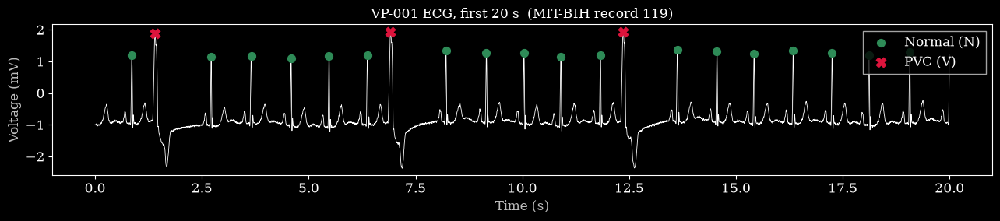

In [5]:
# ── Visualize first 20 s of ECG (provided) ───────────────────────────────────
T_SHOW = 20  # seconds
mask = time < T_SHOW
in_win_N = samples_N[samples_N < T_SHOW * fs_ecg]
in_win_V = samples_V[samples_V < T_SHOW * fs_ecg]

fig, ax = plt.subplots(figsize=(13, 3))
ax.plot(time[mask], ecg[mask], linewidth=0.6, color="white")
ax.scatter(
    in_win_N / fs_ecg,
    ecg[in_win_N],
    color="seagreen",
    s=50,
    zorder=3,
    label="Normal (N)",
)
ax.scatter(
    in_win_V / fs_ecg,
    ecg[in_win_V],
    color="crimson",
    s=80,
    marker="X",
    zorder=3,
    label="PVC (V)",
)
ax.set_xlabel("Time (s)")
ax.set_ylabel(f"Voltage ({record.units[ECG_CHANNEL]})")
ax.set_title(f"VP-001 ECG, first {T_SHOW} s  (MIT-BIH record {ECG_RECORD})")
ax.legend()
plt.tight_layout()
plt.show()

In [6]:
# ── Task 1.1: Recording duration and PVC burden ──────────────────────────────
# 📋 The previous cell already loaded the data. Now compute and store two values.
#    (a) duration_h  is the total recording length in HOURS
#    (b) pvc_burden  is the PVC fraction as a percentage of all annotated beats
#    The prints below then report the three numbers you need.

# ── 🧠 Your solution — Task 1.1 ────────────────────────────────────────────────

def task_1_1(ecg: np.ndarray, t: np.ndarray, sampling_freq: float, n_samples: np.ndarray, v_samples: np.ndarray):
    # Constants
    SECONDS_IN_ONE_MINUTE = 60
    MINUTES_IN_ONE_HOUR = 60
    SECONDS_IN_ONE_HOUR = SECONDS_IN_ONE_MINUTE * MINUTES_IN_ONE_HOUR

    # There are some ways of calculating duration_h
    # 1. First is using the max value of the t array (which is in seconds), and converting to hours
    duration_h = t.max() / SECONDS_IN_ONE_HOUR
    # 2. Second is using the formula ( (number of samples - 1) / frequency), and converting to hours
    duration_h = ((ecg.shape[0] - 1) / sampling_freq) / SECONDS_IN_ONE_HOUR  # TODO: is the -1 right?

    # For pvc_burden, we just need to count the number of normal heartbeats (N)
    normal_beats_count = n_samples.shape[0]
    # and the number of irregular beats (V)
    pvc_beats_count = v_samples.shape[0]
    # which gives us the total amount of heartbeats
    total_beats_count = normal_beats_count + pvc_beats_count
    # and finally calculate pvc_burden
    pvc_burden = (pvc_beats_count / total_beats_count) * 100

    return duration_h, pvc_burden


# Perform task
duration_h, pvc_burden = task_1_1(ecg=ecg, t=time, sampling_freq=fs_ecg, n_samples=samples_N, v_samples=samples_V)

print(f"Recording duration : {duration_h:.2f} h  ({len(ecg)} samples, fs={fs_ecg} Hz)")
print(f"Normal beats (N)   : {len(idx_N):6d}")
print(f"PVC beats    (V)   : {len(idx_V):6d}  →  burden = {pvc_burden:.2f}%")

Recording duration : 0.50 h  (648000 samples, fs=360 Hz)
Normal beats (N)   :   1537
PVC beats    (V)   :    444  →  burden = 22.41%


### 1.2 Echocardiogram: Left Ventricular Geometry

A 2D echocardiogram produces live B-mode ultrasound images of the heart. The **apical 2-chamber (A2C) view** images the left ventricle (LV) along its long axis.

Two frames matter most in each cycle:

| Frame | Description | LV volume |
|-------|-------------|----------|
| **End-diastole (ED)** | Just before contraction, LV fully filled | Maximum (EDV) |
| **End-systole (ES)** | Peak contraction, blood ejected | Minimum (ESV) |

The **Ejection Fraction (EF)** is the primary clinical measure of LV systolic function. It's defined as:

$$\boxed{\text{EF} = \frac{\text{EDV} - \text{ESV}}{\text{EDV}} \times 100\%}$$

Normal is **≥ 55 %**. A value below 40 % indicates heart failure with reduced ejection fraction (HFrEF).

#### 📋 Task 1.2

Run the cells below to load and play the echocardiogram frames. By visual inspection, which frame looks like ED, and which looks like ES?


In [7]:
# ── Load CAMUS echocardiogram frames ──────────────────────────────────────────
# The camus-sample dataset has one patient (patient0401) with two views:
#   - patient0401_2CH_half_sequence.hdf5  →  17 frames  (apical 2-chamber, the view we use)
#   - patient0401_4CH_half_sequence.hdf5  →  15 frames  (apical 4-chamber, not used)
# Loading all 17 frames gives the full ED→ES sequence for the 2CH view.
INFERENCE_SIZE = 256
N_FRAMES = 17

with zea.File(
    "hf://zeahub/camus-sample/val/patient0401/patient0401_2CH_half_sequence.hdf5"
) as file:
    echo_frames = file.data.image.values[:]  # (frames × H × W × channels)

echo_frames = zea.func.translate(echo_frames, (-60, 0), (0, 255))

N_FRAMES = echo_frames.shape[0]  # actual frames returned
print(
    f"Echo frames loaded: frames x height x width = {echo_frames.shape} "
    "complete ED→ES sequence for VP-001, 2CH view"
)

streaming patient0401_2CH_half_sequence.hdf5:   0%|          | 0.00/4.66M [00:00<?, ?B/s]

Echo frames loaded: frames x height x width = (17, 519, 630) complete ED→ES sequence for VP-001, 2CH view


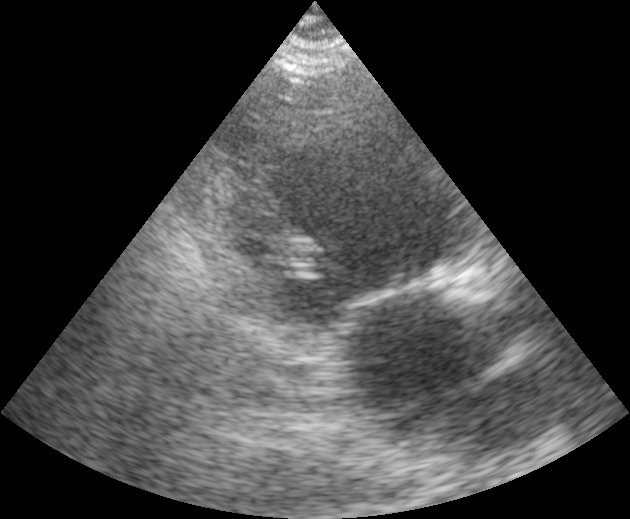

In [8]:
# ── Visualize all echo frames ─────────────────────────────────────────────────
frames = echo_frames.astype(np.uint8)
gif_frames = [Image.fromarray(f) for f in frames]

buf = io.BytesIO()
gif_frames[0].save(
    buf,
    format="GIF",
    save_all=True,
    append_images=gif_frames[1:],
    duration=120,
    loop=0,
)

display(IPyImage(data=buf.getvalue()))

In [9]:
# ── Manual frame inspector (slider) ──────────────────────────────────────────

png_frames = []
for f in frames:
    _buf = io.BytesIO()
    Image.fromarray(f).save(_buf, format="PNG")
    png_frames.append(_buf.getvalue())

img_widget = widgets.Image(value=png_frames[0], format="png")
label = widgets.Label(value="Frame 0")
slider = widgets.IntSlider(
    min=0,
    max=len(frames) - 1,
    value=0,
    description="Frame",
    continuous_update=False,
)


def _on_change(change):
    i = change["new"]
    img_widget.value = png_frames[i]
    label.value = f"Frame {i}"


slider.observe(_on_change, names="value")
display(widgets.VBox([slider, label, img_widget]))

##### 🧠 Your solution — Task 1.2

> In the first frame (frame 0) the Left Ventricle is the most filled, which indicates End-Diastole (ED). In the last frame (frame 16), the Left Ventricle is the most contracted, therefore it indicates End-Systole (ES)


### 1.3 R-Peak Detection from a Noisy ECG via Matched Filter

In Task 1.1 we took the *annotated* R-peak indices as given. Real recordings are rarely that clean. In practice the signals are often corrupted by noise and artifacts. To mimic this more realistic scenario, we will add noise to the clean ECG (Gaussian noise plus a slow baseline drift) and then detect the R-peaks ourselves before any further analysis.

#### Theory: matched filter as the optimal linear detector

Suppose we want to detect a known signal $\mathbf{s}\in\mathbb{R}^N$, the QRS template, buried in additive noise. We design a linear filter with coefficients $\mathbf{h}\in\mathbb{R}^N$ and read its output at the alignment instant. That output is the inner product

$$y \;=\; \mathbf{h}^T \mathbf{s},$$

and the **output SNR**, meaning the signal energy at that instant divided by the filter's noise gain, is proportional to:

$$\mathrm{SNR}\;\propto\;\frac{|\mathbf{h}^T\mathbf{s}|^2}{\|\mathbf{h}\|^2}$$

We want the $\mathbf{h}$ that maximizes this ratio.

The **Cauchy-Schwarz inequality** bounds the numerator by the product of the squared norms:

$$|\mathbf{h}^T\mathbf{s}|^2 \;\leq\; \|\mathbf{h}\|^2 \, \|\mathbf{s}\|^2$$

Substitute that back and the $\|\mathbf{h}\|^2$ terms cancel. What remains is an upper bound set by the **signal energy** $\|\mathbf{s}\|^2$. No linear filter can do better. Cauchy-Schwarz also tells us *when* the bound is reached. It holds **only when $\mathbf{h}$ is proportional to $\mathbf{s}$**, so the two vectors are collinear.

To translate "$\mathbf{h} \propto \mathbf{s}$" into a discrete-time filter, recall what convolution computes at the alignment instant. It is the inner product of $\mathbf{s}$ with the **time-reversed** taps. So the optimal filter is the signal reversed in time:

$$\boxed{\;h_{\mathrm{MF}}[n] \;=\; s[N-1-n]\;}$$

Convolving with $h_{\mathrm{MF}}$ is equivalent to **cross-correlating** the input with the template:

$$y[n] \;=\; (h_{\mathrm{MF}} * x)[n] \;=\; \sum_{k=0}^{N-1} s[k]\, x[n - (N-1) + k]$$

A peak in $y[n]$ marks where a real QRS complex aligns with the template. There is a useful consequence here. Under Gaussian noise this matched filter is **equivalent to the maximum-likelihood / Neyman-Pearson detector**, this will be relevant for the analysis in Part 3.

#### 📋 Task 1.3a

Run the cell below. It builds a QRS template from a single Normal beat, adds synthetic noise (Gaussian plus baseline drift), and plots the clean signal against the noisy one. Now look at the plot. What feature of the noisy signal would cause a plain amplitude threshold to fail?


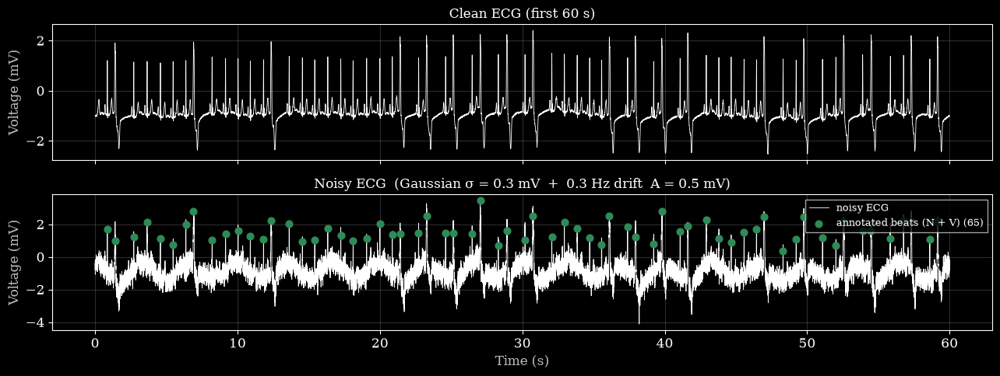

Annotated beats in slice  : 65
QRS template length        : 57 samples (≈ 158 ms wide)


In [10]:
# ── Task 1.3a: Inspect the noisy ECG (provided) ──────────────────────────────
# This cell is fully provided. It builds a QRS template (about 160 ms wide) from
# one Normal beat, adds synthetic noise to the first 60 s of the ECG (Gaussian
# σ = 0.30 mV plus a 0.3 Hz baseline-drift cosine), and plots the clean signal
# next to the noisy one so you can see the kind of artifact a home Holter produces.

# ─── Setup ───────────────────────────────────────────────────────────────────
SLICE_S = 60
slice_n = int(SLICE_S * fs_ecg)
ecg_clean = ecg[:slice_n]
t_slice = np.arange(slice_n) / fs_ecg


# Build QRS template from one Normal beat (~160 ms wide, centered on the R-peak)
def build_qrs_template(sig, beat_idx, fs, half_ms=80):
    half = int(half_ms / 1000 * fs)
    return sig[beat_idx - half : beat_idx + half + 1]


template_idx = int(samples_N[1])
qrs_template = build_qrs_template(ecg, template_idx, fs_ecg)
qrs_template = qrs_template - np.mean(qrs_template)  # zero-mean → robust to DC offsets

# Synthetic noise: Gaussian + low-frequency baseline drift
NOISE_STD = 0.30
DRIFT_AMP = 0.50
ecg_noisy = (
    ecg_clean + rng.normal(0, NOISE_STD, slice_n) + DRIFT_AMP * np.cos(2 * np.pi * 0.3 * t_slice)
)

# Annotated R-peak samples that fall within this slice
# These are all annotated beats (Normal + PVC) in the slice. The matched filter
# detects heartbeats regardless of type. Distinguishing Normal from PVC is a
# separate problem, handled in Part 3 with Neyman-Pearson.
samples_all = np.sort(np.concatenate([samples_N, samples_V]))
ann_in_slice = samples_all[samples_all < slice_n]

# ─── Plot: clean vs noisy ────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(13, 5), sharex=True)
axes[0].plot(t_slice, ecg_clean, color="white", linewidth=0.6)
axes[0].set_ylabel("Voltage (mV)")
axes[0].set_title("Clean ECG (first 60 s)")
axes[0].grid(alpha=0.25)

axes[1].plot(t_slice, ecg_noisy, color="white", linewidth=0.6, label="noisy ECG")
axes[1].scatter(
    ann_in_slice / fs_ecg,
    ecg_noisy[ann_in_slice],
    color="seagreen",
    marker="o",
    s=40,
    zorder=3,
    label=f"annotated beats (N + V) ({len(ann_in_slice)})",
)
axes[1].set_xlabel("Time (s)")
axes[1].set_ylabel("Voltage (mV)")
axes[1].set_title(f"Noisy ECG  (Gaussian σ = {NOISE_STD} mV  +  0.3 Hz drift  A = {DRIFT_AMP} mV)")
axes[1].legend(loc="upper right", fontsize=9)
axes[1].grid(alpha=0.25)
plt.tight_layout()
plt.show()

print(f"Annotated beats in slice  : {len(ann_in_slice)}")
print(
    f"QRS template length        : {len(qrs_template)} samples "
    f"(≈ {1000 * len(qrs_template) / fs_ecg:.0f} ms wide)"
)

##### 🧠 Your solution — Task 1.3a

> The baseline drift shifts the ECG signal up and down over time, so the same amplitude threshold would not work consistently. A threshold high enough to avoid noise in one part of the signal could miss a QRS complex when the baseline is shifted downward, or produce false detections when the baseline shifts upward.
> 
> Also if the Gaussian noise variance is too high then it can also traverse the threshold.


#### 📋 Task 1.3b

Implement the matched filter by **cross-correlating** the noisy ECG with the QRS template. Threshold the output. Then require at least **250 ms** between one detected peak and the next. The reason is simple. A normal heart rate cannot exceed about 240 bpm, so two real R-peaks are always at least 250 ms apart. That spacing also prevents flagging the same QRS complex twice.

#### 📋 Task 1.3c

Now evaluate it against the annotation. Compute the **true-positive rate (TPR / sensitivity)** and the **false-positive count**, counting a detection as correct when it falls within ±50 ms of an annotated peak. Then discuss where plain threshold detection on the matched-filter output falls short.


Sensitivity (true-positive rate)   : 1.0
False positive count               : 0


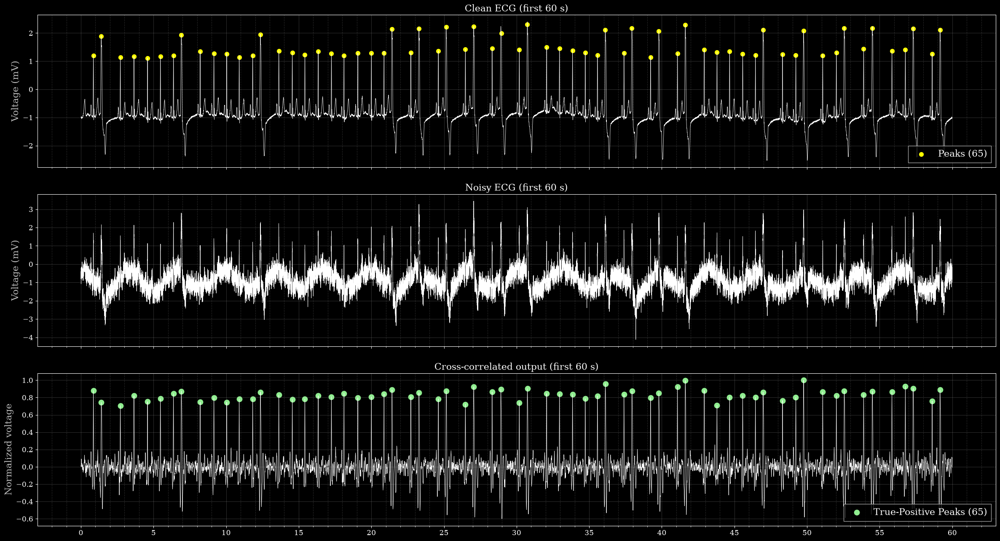

In [ ]:
# ── Task 1.3b/c: Implement and evaluate the matched filter ───────────────────
# 📋 (b i) Build the matched-filter output.
#         Subtract the mean of `ecg_noisy` so DC can't skew it. Cross-correlate
#         that with `qrs_template`. Then divide by the peak absolute value so the
#         result lies on [-1, 1].
#         Useful: scipy.signal.correlate().
#
#     (b ii) Detect candidate R-peaks.
#         Threshold the normalized output, and also require at least 250 ms between
#         detections. A normal heart rate cannot exceed about 240 bpm, so two real
#         R-peaks are always at least 250 ms apart. Convert 250 ms to samples with
#         `fs_ecg`.
#         Useful: scipy.signal.find_peaks().
#
#     (c) Evaluate it against `ann_in_slice`. A detection counts as a true positive
#         when it falls within ±50 ms of an annotated R-peak. Report the TPR
#         (sensitivity) and the false-positive count. Then discuss where plain
#         threshold detection starts to struggle.

# ── 🧠 Your solution — Task 1.3b and 1.3c ───────────────────────────────────────────────

# Get cross-correlated signal
def task_1_3b_i(signal: np.ndarray, template: np.ndarray):
    # Get unbiased signal
    unbiased_signal = signal - np.mean(signal)
    # Match with the template
    corr_signal = scipy.signal.correlate(unbiased_signal, template, method='direct', mode='same')
    # Return the normalized correlated signal
    return corr_signal / max(corr_signal)


# Get candidate peaks
def task_1_3b_ii(signal: np.ndarray, sampling_freq: float):
    # Constants
    MINIMUM_PTP_TIME_DIST = 250e-3
    MINIMUM_PTP_SAMPLE_DIST = (MINIMUM_PTP_TIME_DIST * sampling_freq) + 1  # TODO: is the +1 right?
    # TODO: pick a less arbitrary treshold. For example, see whats the max non peak val, that is,
    #       excluding peaks and its proximities. then see whats the min peak value, and compare both.
    AMPLITUDE_TRESHOLD = 0.6

    # Return candidate peaks
    return scipy.signal.find_peaks(signal, height=AMPLITUDE_TRESHOLD, distance=MINIMUM_PTP_SAMPLE_DIST)


# Get specificity and false positive count for the peaks predicted with cross-correlation
def task_1_3c(predicted_peak_samples: np.ndarray, true_peak_samples: np.ndarray, sampling_freq: float):
    # Constants
    MINIMUM_TIME_TOLERANCE = 50e-3
    MINIMUM_SAMPLE_TOLERANCE = (MINIMUM_TIME_TOLERANCE * sampling_freq) + 1  # TODO: is the +1 right?

    # Create lists for true positives and false positives
    true_positive_peaks = list()
    false_positive_peaks = list()

    # Check if each predicted peak is a true-positive or a false-positive
    for peak in predicted_peak_samples:
        distance_to_nearest_true_peak = np.min((np.abs(true_peak_samples - peak)))
        if distance_to_nearest_true_peak < MINIMUM_SAMPLE_TOLERANCE:
            true_positive_peaks.append(peak)
        else:
            false_positive_peaks.append(peak)

    # Calculate confusion matrix
    false_positive_count = len(false_positive_peaks)
    sensitivity = len(true_positive_peaks) / len(true_peak_samples)

    # Print and return the required outputs
    print(f"Sensitivity (true-positive rate)   : {sensitivity:.3}")
    print(f"False positive count               : {false_positive_count}")
    return np.array(true_positive_peaks), np.array(false_positive_peaks)


# Plot ECGs to understand results better
def plot_ecgs(
    t_slice: np.ndarray,
    clean_ecg_slice: np.ndarray,
    noisy_ecg_slice: np.ndarray,
    corrrelated_ecg_slice: np.ndarray,
    true_peak_samples: np.ndarray,
    tp_peak_samples: np.ndarray,
    fp_peak_samples: np.ndarray,
    sampling_freq: float
):
    from matplotlib.ticker import MultipleLocator
    fig, axes = plt.subplots(3, 1, figsize=(24, 13), sharex=True)


    # Plot original, clean ECG (for the first 60 seconds)
    axes[0].plot(t_slice, clean_ecg_slice, color="white", linewidth=0.6)
    # Plot true peaks
    axes[0].scatter(
        true_peak_samples / sampling_freq,
        clean_ecg_slice[true_peak_samples],
        color="yellow",
        marker="o",
        s=50,
        label=f"Peaks ({len(true_peak_samples)})",
    )
    axes[0].set_title("Clean ECG (first 60 s)", fontsize=16)
    axes[0].set_ylabel("Voltage (mV)", fontsize=16)
    axes[0].legend(loc="lower right", fontsize=16)

    # Plot artificially-noisy ECG (for the first 60 seconds)
    axes[1].plot(t_slice, noisy_ecg_slice, color="white", linewidth=0.6)
    axes[1].set_title("Noisy ECG (first 60 s)", fontsize=16)
    axes[1].set_ylabel("Voltage (mV)", fontsize=16)

    # Plot ECG signal reconstructed after cross-correlation
    axes[2].plot(t_slice, corrrelated_ecg_slice, color="white", linewidth=0.6)
    # Plot true-positive peaks found
    axes[2].scatter(
        tp_peak_samples / sampling_freq,
        corrrelated_ecg_slice[tp_peak_samples],
        color="lightgreen",
        marker="o",
        s=80,
        label=f"True-Positive Peaks ({len(tp_peak_samples)})",
    )
    # Plot false-positive peaks found, when these exist
    if fp_peak_samples.size:
        axes[2].scatter(
            fp_peak_samples / sampling_freq,
            corrrelated_ecg_slice[fp_peak_samples],
            color="red",
            marker="x",
            s=80,
            label=f"False-Negative Peaks ({len(fp_peak_samples)})",
        )
    axes[2].set_title("Cross-correlated output (first 60 s)", fontsize=16)
    axes[2].set_ylabel("Normalized voltage", fontsize=16)
    axes[2].legend(loc="lower right", fontsize=16)

    # Small visual changes
    for ax in axes:
        ax.xaxis.set_major_locator(MultipleLocator(5))
        ax.xaxis.set_minor_locator(MultipleLocator(1))
        ax.grid(which="major", axis="both", alpha=0.25)
        ax.grid(which="minor", axis="x", linestyle="--", alpha=0.2)

    # Show graphs
    plt.tight_layout(h_pad=2)
    plt.show()



# Perform tasks
corr_signal = task_1_3b_i(signal=ecg_noisy, template=qrs_template)
predicted_peaks = task_1_3b_ii(signal=corr_signal, sampling_freq=fs_ecg)
tp_peak_samples, fp_peak_samples = task_1_3c(
    predicted_peak_samples=predicted_peaks[0],
    true_peak_samples=ann_in_slice,
    sampling_freq=fs_ecg
)

# Extra: plot graphs to get better insight
plot_ecgs(t_slice=t_slice, clean_ecg_slice=ecg_clean, noisy_ecg_slice=ecg_noisy,
          corrrelated_ecg_slice=corr_signal, true_peak_samples=ann_in_slice,
          tp_peak_samples=tp_peak_samples, fp_peak_samples=fp_peak_samples, sampling_freq=fs_ecg)

##### 🧠 Your solution — Task 1.3c

> For the synthetic noisy ECG used here, the matched-filter detector achieved 100% sensitivity with no false positives at the chosen threshold. This shows that the matched filter can be very effective when the QRS morphology is well represented by the template and the noise level is moderate.
>
> However, plain threshold detection still has limitations. The choice of a fixed threshold involves a trade-off: increasing the threshold can reduce false positives but may cause weaker or morphologically different beats to be missed, while lowering the threshold can increase sensitivity at the cost of detecting noise or artefacts as false R-peaks. In addition, the QRS template was obtained from a single Normal beat, so beats with substantially different morphology, may correlate less strongly with the template. Baseline changes and movement artefacts in a real home Holter recording could therefore make a fixed threshold less reliable.
>
> Thus, the 100% sensitivity observed in this synthetic test does not mean that threshold detection is universally reliable; it means that it performed well for this specific signal and noise realisation.


---
## Part 2 · HRV: Distribution Fitting & Spectral Analysis (35 pts)

### 2.1 The R-R Interval Series as a Random Process

The sequence of inter-beat intervals $\{T_k\}$ (R-R intervals, in seconds) is a discrete-time random process. Under normal sinus rhythm it can be modeled as **wide-sense stationary (WSS)**:

$$E[T_k] = \mu_T = \text{const}, \qquad R_{TT}[m] = E[T_k\,T_{k+m}] \text{ depends only on lag } m$$

**Heart rate variability (HRV)** quantifies the beat-to-beat fluctuations. These changes are driven by the autonomic nervous system, which constantly balances its sympathetic branch (which speeds the heart up) against its parasympathetic or vagal branch (which slows it down). Higher variability generally reflects a healthier, more adaptable heart, so a reduced HRV is a recognized marker of cardiac risk. Time-domain metrics:

| Metric | Formula | Clinical interpretation |
|--------|---------|------------------------|
| Mean RR | $\bar{T} = \frac{1}{N}\sum_{k=1}^N T_k$ | Average heart rate |
| SDNN | $\sqrt{\frac{1}{N-1}\sum_k (T_k - \bar{T})^2}$ | Overall HRV, reflects all cyclic components |
| RMSSD | $\sqrt{\frac{1}{N-1}\sum_k (T_{k+1}-T_k)^2}$ | Short-term HRV, parasympathetic tone |

#### 📋 Task 2.1

Compute mean RR, SDNN, and RMSSD for the *Normal beats only* (exclude PVC intervals, which would bias the estimate). Convert mean RR to heart rate in bpm.

In [12]:
# ── Extract R-R intervals (provided) ─────────────────────────────────────────
# We use every annotated beat here.
rr_all = np.diff(samples) / fs_ecg  # all intervals (s)
rr_symbols = symbols[1:]  # symbol of the beat that ENDS each interval (length N-1)

# Normal-beat intervals only: both bounding beats must be Normal (N→N).
# This excludes N→V (short pre-ectopic interval) and V→N (compensatory pause),
# both of which inflate SDNN and RMSSD when PVC burden is high.
rr_N = rr_all[(symbols[:-1] == "N") & (symbols[1:] == "N")]
rr_V = rr_all[(symbols[:-1] == "V")]  # all intervals ending with PVC (V), i.e. N→V and V→V

print(f"Total R-R intervals  : {len(rr_all):6d}")
print(f"  ↳ N→N (pure sinus) : {len(rr_N):6d}")
print(f"  ↳ ending PVC    (V): {len(rr_V):6d}")

Total R-R intervals  :   2087
  ↳ N→N (pure sinus) :   1091
  ↳ ending PVC    (V):    444


In [13]:
# ── Task 2.1: HRV time-domain metrics ────────────────────────────────────────
# 📋 Use rr_N (Normal R-R intervals only) for an unbiased HRV estimate.
#    PVC intervals are excluded because they contain a short pre-ectopic interval
#    followed by a long compensatory pause, which inflates SDNN and RMSSD.

# ── 🧠 Your solution — Task 2.1 ────────────────────────────────────────────────
#    Required outputs (used by the printout below):
#      mean_rr  – mean Normal R-R interval (s)
#      hr_bpm   – heart rate (bpm)
#      sdnn     – SDNN, beat-to-beat variability (s)
#      rmssd    – RMSSD, short-term variability (s)

def task_2_1(n_intervals: np.ndarray):
    SECONDS_IN_ONE_MINUTE = 60

    # The mean is easy enough to calculate using numpy
    mean_rr = np.mean(n_intervals)

    # mean_rr is a period in seconds. To calculate the frequency in minutes (bpm), we do (1/bpm)*60
    hr_bpm = (1/mean_rr) * SECONDS_IN_ONE_MINUTE

    # SDNN is just the standard deviation for the sample, which we can also use numpy for
    sdnn = np.std(n_intervals, ddof=1)

    # We calculate RMSSD more explicitly
    # First, we calculate the first difference for the intervals
    rr_first_diff = np.diff(n_intervals)
    # We then take the square of the sum of squares (which is equivalent to the norm function)
    rr_first_diff_norm = np.linalg.norm(rr_first_diff)
    # And finally we divide by the square root of the sample size - 1
    rmssd = rr_first_diff_norm / np.sqrt(len(rr_first_diff))

    return mean_rr, hr_bpm, sdnn, rmssd

# Perform task
mean_rr, hr_bpm, sdnn, rmssd = task_2_1(n_intervals=rr_N)


print(f"Mean RR  : {mean_rr:.3f} s   →   HR = {hr_bpm:.1f} bpm")
print(f"SDNN     : {sdnn * 1000:.1f} ms   (healthy adult rest: 30–100 ms)")
print(f"RMSSD    : {rmssd * 1000:.1f} ms   (healthy adult rest: 20–60 ms)")

Mean RR  : 0.901 s   →   HR = 66.6 bpm
SDNN     : 41.4 ms   (healthy adult rest: 30–100 ms)
RMSSD    : 36.1 ms   (healthy adult rest: 20–60 ms)


### 2.2 Distribution Fitting via Least-Squares (Gauss-Newton)

In Task 2.1 you computed the sample mean and sample standard deviation of $\{T_k\}$. Under a Gaussian assumption, the **sample mean is exactly the MLE** for $\mu$ (Ch 7). The **unbiased sample variance** differs from the MLE variance only by an $N/(N-1)$ correction, which is negligible for $N \gg 1$:

$$\hat\mu_{\mathrm{MLE}} = \frac{1}{N}\sum_{k=1}^{N} T_k, \qquad \hat\sigma^2_{\mathrm{MLE}} = \frac{1}{N}\sum_{k=1}^{N} (T_k - \hat\mu)^2$$

A second route to the same parameters is **least-squares fitting of the histogram** (Ch 9). Here we do not maximize the likelihood of the i.i.d. samples; we minimize the squared error between the empirical histogram and the predicted Gaussian PDF.

#### Problem setup

Given the histogram $\{(x_i, y_i)\}_{i=1}^{B}$ where $x_i$ is the bin center and $y_i$ is the normalized bin count (PDF estimate), we minimize:

$$S(\boldsymbol\theta) = \sum_{i=1}^{B} \big(y_i - p(x_i \mid \boldsymbol\theta)\big)^2, \qquad p(x\mid\boldsymbol\theta) = \frac{1}{\sqrt{2\pi\sigma^2}}\,\exp\!\left(-\frac{(x-\mu)^2}{2\sigma^2}\right),\quad \boldsymbol\theta = [\mu,\sigma]^T$$

This objective is non-linear in $\boldsymbol\theta$, so we cannot solve it in closed form. We apply the **Gauss-Newton** iteration:

$$\Delta\boldsymbol\theta = (J^T J)^{-1} J^T \boldsymbol\varepsilon,\qquad \boldsymbol\theta_{k+1} = \boldsymbol\theta_k + \alpha\, \Delta\boldsymbol\theta_k$$

where $\boldsymbol\varepsilon = \boldsymbol y - p(\boldsymbol x \mid \boldsymbol\theta)$ and the Jacobian $J\in\mathbb{R}^{B\times 2}$ collects the partial derivatives of $p$ with respect to the parameters.


#### 📋 Task 2.2a

Hand-derive the partial derivatives $\partial p/\partial\mu$ and $\partial p/\partial\sigma$ of the Gaussian PDF. Write out the Jacobian matrix $J$ explicitly.


##### 🧠 Your solution — Task 2.2a

### Task 2.2a – Partial Derivatives and Jacobian

The Gaussian PDF is

$$
p(x \mid \mu,\sigma)
=
\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\left(
-\frac{(x-\mu)^2}{2\sigma^2}
\right),
$$

where $\sigma > 0$.

The partial derivatives are derived with respect to $\mu$ and $\sigma$.

#### Partial derivative with respect to $\mu$

Only the exponential term depends on $\mu$. Using the chain rule,

$$
\frac{\partial p}{\partial\mu}
=
p(x\mid\mu,\sigma)
\frac{\partial}{\partial\mu}
\left[
-\frac{(x-\mu)^2}{2\sigma^2}
\right].
$$

The derivative of the exponent is

$$
\frac{\partial}{\partial\mu}
\left[
-\frac{(x-\mu)^2}{2\sigma^2}
\right]
=
\frac{x-\mu}{\sigma^2}.
$$

Therefore,

$$
\boxed{
\frac{\partial p}{\partial\mu}
=
p(x\mid\mu,\sigma)
\frac{x-\mu}{\sigma^2}
}
$$

or, by substituting the Gaussian PDF,

$$
\boxed{
\frac{\partial p}{\partial\mu}
=
\frac{x-\mu}{\sigma^2}
\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\left(
-\frac{(x-\mu)^2}{2\sigma^2}
\right)
}
$$

#### Partial derivative with respect to $\sigma$

The PDF is differentiated using the product rule.

The derivative of the prefactor is

$$
\frac{\partial}{\partial\sigma}
\left(
\frac{1}{\sqrt{2\pi}}\sigma^{-1}
\right)
=
-\frac{1}{\sqrt{2\pi}}\sigma^{-2}.
$$

For the exponential term, using the chain rule,

$$
\frac{\partial}{\partial\sigma}
\left[
-\frac{(x-\mu)^2}{2\sigma^2}
\right]
=
\frac{(x-\mu)^2}{\sigma^3}.
$$

Thus,

$$
\frac{\partial p}{\partial\sigma}
=
p(x\mid\mu,\sigma)
\left[
-\frac{1}{\sigma}
+
\frac{(x-\mu)^2}{\sigma^3}
\right].
$$

Therefore,

$$
\boxed{
\frac{\partial p}{\partial\sigma}
=
p(x\mid\mu,\sigma)
\left(
\frac{(x-\mu)^2}{\sigma^3}
-
\frac{1}{\sigma}
\right)
}
$$

or equivalently,

$$
\boxed{
\frac{\partial p}{\partial\sigma}
=
p(x\mid\mu,\sigma)
\frac{(x-\mu)^2-\sigma^2}{\sigma^3}
}
$$

### Jacobian matrix

For each histogram bin $x_i$, the model prediction is

$$
p_i = p(x_i\mid\mu,\sigma).
$$

The Jacobian $J\in\mathbb{R}^{B\times2}$ contains the partial derivatives of the predicted PDF with respect to $\mu$ and $\sigma$:

$$
J
=
\begin{bmatrix}
\frac{\partial p(x_1\mid\mu,\sigma)}{\partial\mu}
&
\frac{\partial p(x_1\mid\mu,\sigma)}{\partial\sigma}
\\[6pt]
\frac{\partial p(x_2\mid\mu,\sigma)}{\partial\mu}
&
\frac{\partial p(x_2\mid\mu,\sigma)}{\partial\sigma}
\\
\vdots
&
\vdots
\\
\frac{\partial p(x_B\mid\mu,\sigma)}{\partial\mu}
&
\frac{\partial p(x_B\mid\mu,\sigma)}{\partial\sigma}
\end{bmatrix}.
$$

Using the derivatives above,

$$
\boxed{
J_i
=
\begin{bmatrix}
p(x_i\mid\mu,\sigma)\dfrac{x_i-\mu}{\sigma^2}
&
p(x_i\mid\mu,\sigma)
\left(
\dfrac{(x_i-\mu)^2}{\sigma^3}
-
\dfrac{1}{\sigma}
\right)
\end{bmatrix}
}
$$

so the complete Jacobian is

$$
\boxed{
J
=
\begin{bmatrix}
p_1\dfrac{x_1-\mu}{\sigma^2}
&
p_1\left(
\dfrac{(x_1-\mu)^2}{\sigma^3}-\dfrac{1}{\sigma}
\right)
\\[8pt]
p_2\dfrac{x_2-\mu}{\sigma^2}
&
p_2\left(
\dfrac{(x_2-\mu)^2}{\sigma^3}-\dfrac{1}{\sigma}
\right)
\\
\vdots
&
\vdots
\\[4pt]
p_B\dfrac{x_B-\mu}{\sigma^2}
&
p_B\left(
\dfrac{(x_B-\mu)^2}{\sigma^3}-\dfrac{1}{\sigma}
\right)
\end{bmatrix}
}
$$

where

$$
p_i
=
\frac{1}{\sqrt{2\pi\sigma^2}}
\exp\left(
-\frac{(x_i-\mu)^2}{2\sigma^2}
\right).
$$


#### 📋 Task 2.2b

Implement the Gauss-Newton iteration **from scratch** (do not use a built-in optimizer for this part). You may evaluate the Gaussian PDF with `scipy.stats.norm.pdf` (already imported). Only the Gauss-Newton update itself must be coded by hand. Use tolerance $10^{-6}$, maximum 100 iterations, learning rate $\alpha = 1.0$, and initialise from $[\mu_0, \sigma_0]$ = sample moments of the data. Track the sum-of-squared errors per iteration and plot it on a `semilogy` axis to visualize convergence. Report your converged $\hat\mu$ and $\hat\sigma$.

Iterations    5
Final SSE     21.2610
Converged μ   0.9020
Converged σ   0.0340


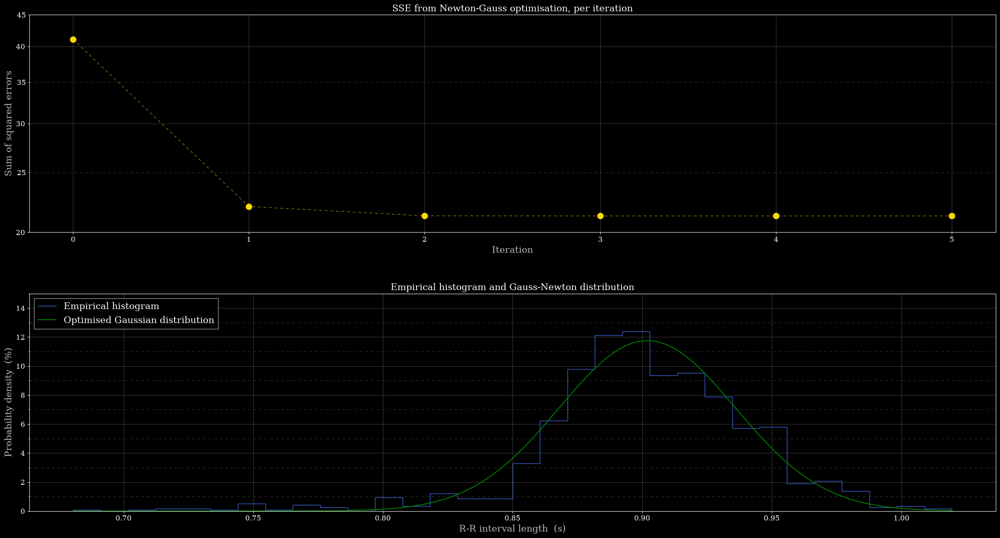

In [14]:
# ── Task 2.2b: Gauss-Newton LSE fit (from scratch) ──────────────────────
# 📋 Build a histogram of rr_N (~30 bins, density=True), then implement
#    Gauss-Newton from scratch (Jacobian from Task 2.2a). Track the SSE per
#    iteration, plot it on a semilogy axis, and report the converged mu, sigma.
#    Useful: np.histogram, np.linalg.solve.

# ── 🧠 Your solution — Task 2.2b ────────────────────────────────────────────────

#  ─────────────────────────────  Helper functions  ───────────────────────────────
def gauss_newton_optimiser(x: np.ndarray, y: np.ndarray, initial_theta: np.ndarray,
                           learning_rate: float, tolerance: float, max_iterations: int):
    # Imports (makes the pdf signature more readable)
    from functools import partial

    # Initialize loop variables
    current_iter = 0
    iter_delta = np.inf
    theta = initial_theta
    sse_per_iteration = []

    # Run optimisation loop
    while ((current_iter < max_iterations) and (iter_delta > tolerance)):
        # Get current parameters and corresponding PDF
        mu, sigma = theta
        estimated_pdf = partial(scipy.stats.norm.pdf, loc=mu, scale=sigma)

        # Calculate epsilon and J for each iteration
        epsilon = y - estimated_pdf(x)
        j_matrix = np.array([
            [((xi-mu)/(sigma**2))*estimated_pdf(xi), (((xi-mu)**2 - sigma**2)/(sigma**3))*estimated_pdf(xi)]
            for xi in x
        ])
        # Calculate current sum of squared errors
        sse_per_iteration.append(epsilon @ epsilon)

        # Update parameters
        delta_theta = np.linalg.solve(j_matrix.T @ j_matrix, j_matrix.T @ epsilon)
        theta_update = learning_rate * delta_theta
        theta += theta_update

        # Update loop variables
        iter_delta = np.linalg.norm(theta_update)
        current_iter += 1

    # Calculate the final SSE, after opimisation is over
    converged_pdf = partial(scipy.stats.norm.pdf, loc=theta[0], scale=theta[1])
    final_epsilon = y - converged_pdf(x)
    sse_per_iteration.append(final_epsilon @ final_epsilon)

    # Return final results
    return theta, np.array(sse_per_iteration)


def plot_gauss_newton_results(mu: float, sigma: float, sse_per_iteration: np.ndarray, bin_edges: np.ndarray, bin_counts: np.ndarray):
    # Imports
    from matplotlib.ticker import ScalarFormatter, MultipleLocator

    fig, axes = plt.subplots(2, 1, figsize=(24, 13))

    # Plot SSE per iteration, in a log scale
    axes[0].semilogy(range(len(sse_per_iteration)), sse_per_iteration, color="gold",
                     marker="o", ms=10, linestyle=(0, (8, 8)), linewidth=0.6)
    axes[0].set_title("SSE from Newton-Gauss optimisation, per iteration", fontsize=16)
    axes[0].set_xlabel("Iteration", fontsize=16)
    axes[0].set_ylabel("Sum of squared errors", fontsize=16)
    axes[0].yaxis.set_major_locator(MultipleLocator(10))
    axes[0].yaxis.set_minor_locator(MultipleLocator(5))
    axes[0].yaxis.set_major_formatter(ScalarFormatter())
    axes[0].yaxis.set_minor_formatter(ScalarFormatter())
    axes[0].set_ylim(bottom=20, top=45)

    # Plot empirical histogram overlayed with the Gaussian distro found after optimisation
    gaussian_x_range = np.linspace(bin_edges[0], bin_edges[-1], 1000)
    axes[1].stairs(bin_counts, bin_edges, color="royalblue", label="Empirical histogram")
    axes[1].plot(gaussian_x_range, scipy.stats.norm.pdf(gaussian_x_range, loc=mu, scale=sigma),
                 color="green", label="Optimised Gaussian distribution")
    axes[1].set_title("Empirical histogram and Gauss-Newton distribution", fontsize=16)
    axes[1].set_xlabel("R-R interval length  (s)", fontsize=16)
    axes[1].set_ylabel("Probability density  (%)", fontsize=16)
    axes[1].legend(loc="upper left", fontsize=16)
    axes[1].yaxis.set_major_locator(MultipleLocator(2))
    axes[1].yaxis.set_minor_locator(MultipleLocator(1))
    axes[1].set_ylim(top=15)

    # Small visual changes
    for ax in axes:
        ax.grid(which="major", axis="both", alpha=0.35)
        ax.grid(which="minor", axis="both", linestyle=(0, (6, 6)), alpha=0.3)

    plt.tight_layout(h_pad=4)
    plt.show()


#  ─────────────────────────────  Main function  ───────────────────────────────
def task_2_2b(n_intervals: np.ndarray, bins_num: int):
    # Hyperparameters for the optimiser, as constants
    TOL = 10e-6
    MAX_ITER = 100
    LEARNING_RATE = 1.0

    # Build histrogram
    bin_counts, bins_edges = np.histogram(n_intervals, bins=bins_num, density=True)
    # Get midpoints which will be used during optimization
    hist_bins_midpoints = (bins_edges[:-1] + bins_edges[1:]) / 2

    # Run the Gauss Newton method, and get the optimised params and distribution
    (converged_mu, converged_sigma), sse_per_iteration = gauss_newton_optimiser(
        x=hist_bins_midpoints,
        y=bin_counts,
        initial_theta=np.array([mean_rr, sdnn]),
        learning_rate=LEARNING_RATE,
        tolerance=TOL,
        max_iterations=MAX_ITER
    )

    # Print and plot results
    print(f"Iterations    {len(sse_per_iteration) - 1}")
    print(f"Final SSE     {sse_per_iteration[-1]:.4f}")
    print(f"Converged \u03BC   {converged_mu:.4f}")
    print(f"Converged \u03C3   {converged_sigma:.4f}")
    plot_gauss_newton_results(
        mu=converged_mu,
        sigma=converged_sigma,
        sse_per_iteration=sse_per_iteration,
        bin_edges=bins_edges,
        bin_counts=bin_counts
    )


# Execute task
task_2_2b(n_intervals=rr_N, bins_num=32)

#### 📋 Task 2.2c

Run `scipy.optimize.curve_fit` on the same histogram and compare. Then compare both LSE estimates against the MLE estimates from Task 2.1. Are they identical? Explain why or why not in 1–2 sentences. *Hint: think about what each method optimizes, the likelihood of samples versus the squared error on bin counts.*

In [15]:
# ── Task 2.2c: Compare LSE (curve_fit) against MLE ──────────────────────
# 📋 Fit the same histogram (x, y) with scipy.optimize.curve_fit and compare
#    to your Gauss-Newton result. Also compare both LSE fits to the MLE from 2.1.
#    Explain any difference in the markdown solution cell below.

# ── 🧠 Your solution — Task 2.2c ────────────────────────────────────────────────

def task_2_2c(n_intervals: np.ndarray, bins_num: int):
    # Build histrogram
    bin_counts, bins_edges = np.histogram(n_intervals, bins=bins_num, density=True)
    # Get midpoints which will be used during optimization
    hist_bins_midpoints = (bins_edges[:-1] + bins_edges[1:]) / 2

    # Call the built-in optimiser
    (fitted_mu, fitted_sigma), _ = scipy.optimize.curve_fit(
        f=lambda x, mu, sigma: scipy.stats.norm.pdf(x, loc=mu, scale=sigma),
        xdata=hist_bins_midpoints,
        ydata=bin_counts
    )

    # Print and return values
    print(f"Fitted \u03BC   {fitted_mu:.4f}")
    print(f"Fitted \u03C3   {fitted_sigma:.4f}")
    return fitted_mu, fitted_sigma,

# Execute task
fitted_mu, fitted_sigma = task_2_2c(n_intervals=rr_N, bins_num=32)
# TODO: dont really get why this is being asked for here? Its not even defined in the task
x_plot = np.linspace(min(rr_N), max(rr_N), 1000)

Fitted μ   0.9020
Fitted σ   0.0340


##### 🧠 Your solution — Task 2.2c

> The Gauss–Newton and curve_fit LSE estimates are the same because both minimise the sum of squared errors between the Gaussian PDF and the histogram values. They are not identical to the MLE estimates because MLE maximises the likelihood of the individual RR samples, whereas LSE fits the Gaussian to binned histogram counts.


### 2.3 HRV Spectral Analysis: Estimator Choice & Uncertainty

**Research question.** *Estimate the LF/HF power ratio of VP-001's R-R interval series, and report it together with a quantified uncertainty.* Your choice of estimator, window and assumptions is part of the answer.

#### Background

The PSD of the R-R series decomposes HRV into three frequency bands:

| Band | Range | Source |
|------|-------|--------|
| VLF | 0.003–0.04 Hz | thermoregulation, renin-angiotensin |
| **LF** | **0.04–0.15 Hz** | sympathetic + parasympathetic (baroreflex) |
| **HF** | **0.15–0.40 Hz** | parasympathetic / respiratory sinus arrhythmia |

Because the sympathetic and parasympathetic branches act on different time scales, they appear in different frequency bands. The **LF/HF ratio** is therefore read as a rough index of sympathovagal balance, where a higher ratio points to sympathetic (stress) dominance and a lower ratio points to parasympathetic (rest) dominance.

The R-R sequence is non-uniformly sampled. A uniform 4 Hz resampling step is provided in the cell below.

#### Methods that you can use

 The course has given you several estimators. Pick from the list of methods below and justify your choices.

| Choice | Options | Course chapter |
|---|---|---|
| Window | rectangular, Hann, Hamming, Blackman, … | Ch 11 |
| Non-parametric estimator | periodogram, Bartlett, Welch (WOSA), Blackman-Tukey | Ch 12 |
| Parametric model | AR via Yule-Walker | Ch 13 |


In [16]:
# ── Resampling to uniform grid (provided) ────────────────────────────────────
# We restrict the HRV analysis to the first 15 minutes of the recording,
# where the R-R series is approximately stationary (verify in Task 2.3a).
# The full 30-minute record is still used in Part 3 for arrhythmia detection.
# The time axis below uses real wall-clock beat times. This is necessary because
# the N→N filter excludes intervals around PVCs, leaving real gaps in the series.

fs_rr = 4.0
PART2_DURATION_S = 15 * 60

mask_NN = (symbols[:-1] == "N") & (symbols[1:] == "N")
end_time = samples[1:] / fs_ecg  # wall-clock time of each interval's end
mask_win = end_time < PART2_DURATION_S
mask = mask_NN & mask_win

rr_N_p2 = rr_all[mask]
t_rr = end_time[mask]  # real wall-clock time axis (s)
t_uniform = np.arange(t_rr[0], t_rr[-1], 1.0 / fs_rr)
rr_resampled = np.interp(t_uniform, t_rr, rr_N_p2)

print(f"HRV window           : first {PART2_DURATION_S} s of the recording")
print(f"N→N intervals used   : {len(rr_N_p2)}")
print(
    f"Resampled R-R series : {len(rr_resampled)} samples at {fs_rr} Hz "
    f"(window duration ≈ {len(rr_resampled) / fs_rr:.0f} s)"
)

HRV window           : first 900 s of the recording
N→N intervals used   : 594
Resampled R-R series : 3580 samples at 4.0 Hz (window duration ≈ 895 s)


#### 📋 Task 2.3a — Validate the WSS assumption

Task 2.1 modeled $\{T_k\}$ as wide-sense stationary. The PSD framework requires this. Empirically test it on this record: state your test, your result, and the consequences for what follows.


In [17]:
# ── Task 2.3a: Test the WSS assumption ───────────────────────────────────────
# 📋The PSD framework requires the R-R series to be WSS. Test it.
#    Recall the WSS conditions: (i) constant mean, (ii) constant variance,
#    (iii) autocorrelation depending only on lag.
#
#    You decide *how* to test.  Choose an approach you can
#    justify. State your conclusion in the markdown cell below.

#    Might be useful: np.array_split, scipy.ndimage.uniform_filter1d (sliding-window
#    moments without boundary artifacts), np.correlate (autocorrelation per segment).

# ── 🧠 Your solution — Task 2.3a ───────────────────────────────────────────────
# ... your code here ...




##### 🧠 Your solution — Task 2.3a

> Write your explanation here.


#### 📋 Task 2.3b — Pick non-parametric estimators

Implement at least **two** estimators from the methods in Ch 12. Plot them on the same axes. Justify your final choice for this record in terms of the bias–variance tradeoff and the role of windowing in spectral leakage across the LF/HF boundary at 0.15 Hz. Compute and report the resulting LF/HF.


In [18]:
# ── Task 2.3b: Non-parametric estimator comparison ───────────────────────────
# 📋 Implement *at least two* of: periodogram, Bartlett, Welch, Blackman-Tukey.
#    Plot on the same axes. Discuss bias–variance and leakage at 0.15 Hz.
#
#    Useful: scipy.signal.welch, scipy.signal.periodogram, scipy.signal.windows, np.trapezoid (for band-power integration).
#
#    Compute LF/HF from your chosen estimate via trapezoidal integration:
#        mask = (freqs >= f_low) & (freqs <= f_high)
#        band_power = np.trapezoid(psd[mask], freqs[mask])

# ── 🧠 Your solution — Task 2.3b ───────────────────────────────────────────────
# ... your code here ...




##### 🧠 Your solution — Task 2.3b

> Write your explanation here.


#### 📋 Task 2.3c — Fit a parametric AR model

Fit AR via Yule-Walker. Sweep over a range of orders and select $p^*$ by minimizing the AIC. Justify the order range you sweep. Compute and report the AR-based LF/HF.


In [19]:
# ── Task 2.3c: AR fit + AIC order selection ──────────────────────────────────
# 📋 Fit AR(p) via yule_walker over a sweep of orders. Select p* by minimizing
#    the Akaike Information Criterion (Ch 13):
#        AIC(p) = N · ln(σ²(p)) + 2p
#    where σ²(p) is the residual noise variance returned by yule_walker.
#    Justify the order range you sweep.
#
#    Then evaluate the AR PSD and compute LF/HF:
#        P(f) = (σ² / |1 − Σ_k ρ_k · exp(−2πjfk/fs)|²) · (2/fs)

#    Useful: yule_walker (already imported). scipy.signal.freqz is a convenient
#    alternative way to evaluate the AR PSD via the filter denominator.

# ── 🧠 Your solution — Task 2.3c ───────────────────────────────────────────────
# 👇 your solution here — replace each TODO (or leave it if you don't know this task)
best_idx = TODO




##### 🧠 Your solution — Task 2.3c

> Write your explanation here.


#### 📋 Task 2.3d — Reconcile the parametric and non-parametric estimates

(a) Overlay the Welch PSD (generate it, if you did not use it in Task 2.3b) and the AR PSD (from 2.3c) on a single semilog plot, with the LF and HF bands shaded. (b) Print a side-by-side numerical comparison of the LF/HF values produced by each method, including the absolute and relative gap. (c) Discuss in 3-4 sentences. Where do the two PSDs agree visually? Where do they differ, and *why*? Think about each method's underlying assumption (parametric AR model versus averaged periodogram). Which method's character would you trust more for this patient's recording, and what is the trade-off?


In [20]:
# ── Task 2.3d: Reconcile parametric and non-parametric estimators ────────────
# 📋 (a) Overlay the Welch PSD (f_w, P_w from 2.3b) and the AR PSD (f_ar, P_ar
#        from 2.3c) on a single semilog plot. Shade the LF (0.04–0.15 Hz) and
#        HF (0.15–0.40 Hz) bands.
#    (b) Print a side-by-side comparison of the LF/HF values from each method
#        (lf_hf_np from 2.3b, lf_hf_ar from 2.3c) including the absolute gap
#        |Δ| and the relative gap |Δ| / max(LF/HF) in percent.
#    (c) Use the markdown discussion below to comment on agreement / differences
#        and which method you would trust on this record.

# ── 🧠 Your solution — Task 2.3d ───────────────────────────────────────────────
# ... your code here ...




##### 🧠 Your solution — Task 2.3d

> Write your explanation here.


#### 📋 Task 2.3e — Reflect on stationarity

Reflect back on your WSS finding in Task 2.3a. What are the consequences of this finding for the PSD framework and the estimates you obtained in Tasks 2.3b–2.3d?


##### 🧠 Your solution — Task 2.3e

> Write your explanation here.


### 2.4 Time-Frequency Analysis: LF/HF Trajectory

Section 2.3 produced a single LF/HF estimate for the first 15 minutes of the recording, the stretch where the WSS assumption holds. The cardiologist will also want to see whether the autonomic state is **stable across the entire 30-minute Holter** or whether episodes of imbalance appear.

Here we compute LF/HF on sliding windows and plot the trajectory $\widehat{\text{LF/HF}}(t)$. If the WSS test in Task 2.3a failed, this is also the form in which the result should be reported.

#### 📋 Task 2.4

Resample the **full 30-minute** R-R series (using the same real-wall-clock-time construction from Task 2.3, but without the 15-minute restriction). Apply a sliding-window Welch estimator with a 5-minute window and 60 % overlap. For each window, compute the LF and HF band powers and the LF/HF ratio. Plot:
1. LF and HF band powers vs. time (top axis),
2. LF/HF ratio vs. time with the clinical threshold ($\text{LF/HF} = 2$) marked (bottom axis).

Discuss in 2-3 sentences what the trajectory reveals about the patient's autonomic state across the recording, and how this connects to your stationarity finding in Task 2.3a.


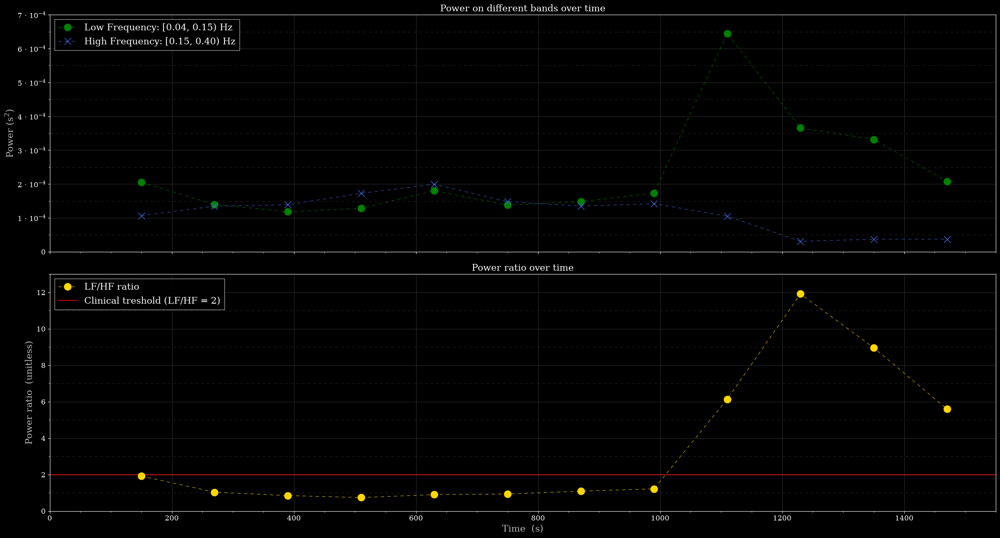

In [22]:
# ── Task 2.4: Time-frequency LF/HF trajectory ────────────────────────────────
# 📋 (1) Resample the FULL 30-minute R-R series (no 15-minute restriction).
#    (2) Sliding-window Welch with a 5-min window and 60% overlap. For each
#        window, integrate over LF (0.04–0.15 Hz) and HF (0.15–0.40 Hz) bands.
#    (3) Plot LF and HF powers (top), LF/HF ratio (bottom). Mark LF/HF=2.

# ── 🧠 Your solution — Task 2.4 ────────────────────────────────────────────────


# Imports
import pandas as pd

# Basically redoing stuff from Task 2.3.
def task_2_4_i(beat_samples: np.ndarray, beat_labels: np.ndarray, intervals: np.ndarray,
               original_sampling_freq: int, resampling_freq: int, time_limit: int):
    # First, filter so we only get R-R intervals labelled as N, happening before the time limit
    normality_mask = (beat_labels[:-1] == "N") & (beat_labels[1:] == "N")
    t_interval_ends = beat_samples[1:] / original_sampling_freq
    mask = normality_mask & (t_interval_ends < time_limit)

    # Filter the R-R intervals and the original times accordingly
    intervals_slice = intervals[mask]
    t_interval_ends_slice = t_interval_ends[mask]

    # Since the filter made the spacing not uniform, resample times and intervals uniformingly
    t_uniform_sampling = np.arange(t_interval_ends_slice[0], t_interval_ends_slice[-1], 1.0 / resampling_freq)
    intervals_uniform_sampling = np.interp(t_uniform_sampling, t_interval_ends_slice, intervals_slice)

    # Return uniformly sampled, normal R-R intervals
    return intervals_uniform_sampling


# This is simply a Welsh estimator.
# We cant simply use scipy.signal.welch() since we need to calculate band powers per window,
# before they are averaged. So we use scipy.signal.periodogram() on a loop
def task_2_4_ii(intervals: np.ndarray, sampling_freq: int, window_time_length: int, overlap_ratio: float):
    # Constants
    LF_BAND_START = 0.04
    LF_BAND_END = 0.15
    HF_BAND_START = 0.15
    HF_BAND_END = 0.4

    # First, we calculate how many samples are included in the window
    window_sample_length = int(window_time_length * sampling_freq)  # TODO: do we need a +1 here or not?
    # And how large is the step between subsequent windows
    window_sample_step = int((1 - overlap_ratio) * window_sample_length)
    # We truncate the number of windows to ignore the last, smaller one.
    windows_num = int((len(intervals) - window_sample_length) // window_sample_step)  # TODO: should we really do this?

    # Create the data structure to hold results
    power_per_band_dict = { "t": [], "lf": [], "hf": [] }

    # For each window, calculate LF and HF power, as in a Welsh estimator with a Hann window
    for i in range(windows_num):
        # Get the intervals in that particular window
        window_start = int(i * window_sample_step)
        window_end = window_start + window_sample_length
        intervals_slice = intervals[window_start : window_end]

        # Calculate the periodogram
        # TODO: is Hann window the best?
        psd_freqs, psd_vals = scipy.signal.periodogram(intervals_slice, fs=sampling_freq, window="hann")

        # We separate according to the frequency band
        lf_mask = (LF_BAND_START <= psd_freqs) & (psd_freqs < LF_BAND_END)
        hf_mask = (HF_BAND_START <= psd_freqs) & (psd_freqs < HF_BAND_END)

        # Get corresponding time for the sample taken
        power_per_band_dict["t"].append((window_start + window_end) // int(2 * sampling_freq))
        # Integrate via trapezoids to obtain band power
        power_per_band_dict["lf"].append(np.trapezoid(y=psd_vals[lf_mask], x=psd_freqs[lf_mask]))
        power_per_band_dict["hf"].append(np.trapezoid(y=psd_vals[hf_mask], x=psd_freqs[hf_mask]))

    # Create df to make things more organized, and easily calculate ratio
    power_per_band_df = pd.DataFrame.from_dict(power_per_band_dict)
    power_per_band_df["ratio"] = power_per_band_df["lf"] / power_per_band_df["hf"]

    # Return the dataframe
    return power_per_band_df


# Plot results
def task_2_4_iii(t: pd.Series, lf_power: pd.Series, hf_power: pd.Series, power_ratio: pd.Series):
    # Imports
    from matplotlib.ticker import MultipleLocator, FuncFormatter

    fig, axes = plt.subplots(2, 1, figsize=(24, 13), sharex=True)

    # Plot LF and HF power
    axes[0].plot(t, lf_power, color="green", marker="o", ms=12, linestyle=(0, (8, 8)),
                 linewidth=0.7, label="Low Frequency: [0.04, 0.15) Hz")
    axes[0].plot(t, hf_power, color="royalblue", marker="x", ms=12, linestyle=(0, (8, 8)),
                 linewidth=0.7, label="High Frequency: [0.15, 0.40) Hz")
    axes[0].yaxis.set_major_locator(MultipleLocator(1e-4))
    axes[0].yaxis.set_minor_locator(MultipleLocator(5e-5))
    axes[0].set_ylim(top=7e-4)
    axes[0].set_title("Power on different bands over time", fontsize=16)
    axes[0].set_ylabel(r"Power ($\mathrm{s}^2$)", fontsize=16)
    axes[0].legend(loc="upper left", fontsize=16)


    # Plot power ratio and clinical treshold
    axes[1].plot(t, power_ratio, color="gold", marker="o", ms=12,
                 linestyle=(0, (8, 8)), linewidth=0.7, label="LF/HF ratio")
    axes[1].plot([0, 1700], [2, 2], color="red", linewidth=1.2,
                 label="Clinical treshold (LF/HF = 2)", zorder=-1)
    axes[1].yaxis.set_major_locator(MultipleLocator(2))
    axes[1].yaxis.set_minor_locator(MultipleLocator(1))
    axes[1].set_ylim(top=13)
    axes[1].set_title("Power ratio over time", fontsize=16)
    axes[1].set_ylabel("Power ratio  (unitless)", fontsize=16)
    axes[1].set_xlabel("Time  (s)", fontsize=16)
    axes[1].legend(loc="upper left", fontsize=16)

    # Small visual changes
    for ax in axes:
        ax.xaxis.set_major_locator(MultipleLocator(200))
        ax.xaxis.set_minor_locator(MultipleLocator(50))
        ax.grid(which="major", axis="both", alpha=0.25)
        ax.grid(which="minor", axis="y", linestyle=(0, (6, 6)), alpha=0.2)
        ax.set_xlim(left=0, right=1550)
        ax.set_ylim(bottom=0)
    # Make y-axis label better looking (albeit the code itself looks ugly :/ )
    axes[0].yaxis.set_major_formatter(
        FuncFormatter(
            lambda y, _: "0" if np.isclose(y, 0)
            else rf"${y * 1e4:g} \, \cdot \, 10^{{-4}}$"
        )
    )

    # Plot results
    plt.tight_layout()
    plt.show()


# Constants
TIME_LIMIT_IN_SECS = 30 * 60
WINDOW_SIZE_IN_SECS = 5 * 60
OVERLAP_RATIO = 0.6

# Execute tasks
intervals_uniform = task_2_4_i(
    beat_samples=samples,
    beat_labels=symbols,
    intervals=rr_all,
    original_sampling_freq=fs_ecg,
    resampling_freq=fs_rr,
    time_limit=TIME_LIMIT_IN_SECS
)

power_per_band_df = task_2_4_ii(
    intervals=intervals_uniform,
    sampling_freq=fs_rr,
    window_time_length=WINDOW_SIZE_IN_SECS,
    overlap_ratio=OVERLAP_RATIO
)

task_2_4_iii(
    t=power_per_band_df["t"],
    lf_power=power_per_band_df["lf"],
    hf_power=power_per_band_df["hf"],
    power_ratio=power_per_band_df["ratio"]
)

##### 🧠 Your solution — Task 2.4

> The LF/HF trajectory stays low and stable (≈1) for the first 16 minutes, consistent with a resting, parasympathetically-dominated state, but then rises sharply around minute 17, peaking near 12 at minute 20 due to a spike in LF power, before gradually decaying back toward baseline. This confirms the Task 2.3a finding that the RR series is only approximately WSS within the first 15 minutes, since the second half of the recording clearly shows non-stationary behaviour. A single global LF/HF estimate over the full 30 minutes would have masked this episode entirely, so the time-resolved view is the appropriate way to report this patient's autonomic state.


---
## Part 3 · Arrhythmia Detection: Multi-Feature Neyman-Pearson (25 pts)

This part builds a PVC detector in four steps. Sub-tasks 3.2–3.4 all place a decision threshold on the **same** feature you design in 3.1. They differ only in *how* the threshold is chosen:

| Sub-task | Question it answers | What you hand in |
|----------|---------------------|------------------|
| **3.1: Feature design** | Which scalar feature best separates Normal vs PVC beats? | code **+ written justification** |
| **3.2: Neyman–Pearson detector** | At a fixed 10 % false-alarm rate, what detection rate results, and how strong is the detector overall (ROC, AUC)? | code (report the printed numbers) |
| **3.3: Youden operating point** | Without fixing $P_{FA}$, which threshold best balances sensitivity and specificity? | code (report the printed numbers) |
| **3.4: Bayesian decision rules** | How do class priors and misclassification costs shift the threshold, and which rule do you use? | code **+ written justification** |

### 3.1 Feature Design

We formulate PVC detection as a **binary hypothesis test** on a scalar feature $x_k$ extracted from the R-R sequence around beat $k$:

$$H_0:\; x \sim \mathcal{N}(\mu_0, \sigma_0^2) \quad \text{(Normal beat)}, \qquad H_1:\; x \sim \mathcal{N}(\mu_1, \sigma_1^2) \quad \text{(PVC beat)}$$

The **quality of your detector depends entirely on how well your feature separates the two classes.** A good feature exploits the characteristic electrophysiological signature of PVCs in the R-R sequence:

| Event | Effect on surrounding R-R intervals |
|-------|-------------------------------------|
| PVC beat itself | Arrives *early* → abnormally short pre-ectopic interval |
| Beat immediately after PVC | Arrives *late* (compensatory pause) → abnormally long post-ectopic interval |
| Sinus beats far from a PVC | Regular interval, approximately constant |

Your task is to design a scalar feature that **aggregates information from a window of $W$ consecutive R-R intervals** ending at beat $k$, such that it takes consistently different values under $H_0$ and $H_1$.

> 📌 **Think about:** Which statistical summary of the window best captures the PVC signature? Mean, variance, the ratio of consecutive intervals? And how wide should the window $W$ be? Too narrow misses the full pattern, too wide dilutes it. One more thing. A Normal beat adjacent to a PVC inherits distorted intervals (the short pre-ectopic or the long compensatory pause). If you include those intervals in your $H_0$ class, what happens to $\sigma_0$ and your AUC?


The **AUC** has the closed-form expression:

$$\text{AUC} = \Phi\!\left(\frac{|\mu_0 - \mu_1|}{\sqrt{\sigma_0^2 + \sigma_1^2}}\right)$$

A higher AUC means better class separation. In other words, a better feature design.

#### 📋 Task 3.1

Design **at least three** candidate scalar features from the R-R sequence. For each, fit Gaussian distributions to the H0 and H1 classes and compute the analytic AUC = Φ(|μ_0 − μ_1| / √(σ_0² + σ_1²)). Pick the **highest-AUC** feature as your detector input, and assign its values to `feat_N` and `feat_V` for use in 3.2–3.4. Present all candidates in a comparison table and justify both your feature pool and your final selection. The three features must capture different parts of the PVC signature; a near-duplicate of another feature does not count. *Aim for AUC ≥ 0.90 with your best feature.*

> ⚙️ Work from `rr_all` (the **original** beat-to-beat intervals, **whole** recording) with labels `rr_symbols`. Do **not** use the resampled `rr_resampled` from Part 2.

> 🎁 **Bonus: go beyond the three required features (+2.5 each, up to +5).** Each *additional* distinct feature beyond the mandatory three earns **+2.5 bonus points**, for up to **2 extra features** (a maximum of **+5**, i.e. five features in total). The same rules apply: a bonus feature must capture yet another part of the PVC signature and be analyzed the same way (its own per-class Gaussian fit and AUC).


In [25]:
# ── Task 3.1: Multi-feature design + per-feature AUC ─────────────────────────
# 📋 Design at least THREE candidate features over a sliding window of W
#    consecutive R-R intervals ending at beat k. The three required features must each capture a different aspect of the PVC signature (not near-duplicates). Each EXTRA feature beyond three
#    is worth +2.5 bonus (up to 2 extra → +5 max). For each feature:
#       (1) build  feat_N (H0)  and  feat_V (H1) class-conditional samples
#       (2) fit a Gaussian per class                       (μ̂, σ̂  by sample moments)
#       (3) compute the closed-form AUC = Φ(|μ_0 − μ_1| / √(σ_0² + σ_1²))
#    Then assign the *best-AUC* feature's arrays to feat_N, feat_V (these are
#    consumed by the NP detector in Task 3.2 and Youden's J in Task 3.3).
#    Use rr_all + rr_symbols (original intervals, whole recording), not rr_resampled.

# ── 🧠 Your solution — Task 3.1 ────────────────────────────────────────────────
#    Required outputs (consumed by the provided code in Tasks 3.2–3.4):
#      feat_N, feat_V    – chosen-feature samples for H0 / H1 (arrays)
#      mu_H0, sigma_H0   – Gaussian fit of feat_N (mean, std)
#      mu_H1, sigma_H1   – Gaussian fit of feat_V (mean, std)
#      x_plot            – feature-range grid for the PDF overlays
# 👇 your solution here — replace each TODO (or leave it if you don't know this task)


# Imports
from typing import List

#  ─────────────────────────────  Helper functions ───────────────────────────────
# Build dataframe with selection of features (both exploratory and final)
def build_features_df(raw_data: np.ndarray, labels: np.ndarray):
    # ────── 1. Data preprocessing ──────
    # Build base df
    feat_df = pd.DataFrame.from_dict({
        "class": labels,
        "last_interval": raw_data,
        "last_n_intervals": [ np.array([]) for x in range(len(rr_all)) ]
    })

    # ────── 2. Data filtering ──────
    # Filter datapoints to only include heartbeat labels (V and N)
    feat_df = feat_df[(feat_df["class"] == "N") | (feat_df["class"] == "V")].reset_index(drop=True)

    #  ────── 3. Feature engineering ──────
    # Helper row: subset of N intervals before the beat
    N = 30
    last_n_intervals = []
    for idx, row in feat_df.iterrows():
        start_idx = idx - N + 1 if (idx - N + 1 > 0) else 0
        last_n_intervals.append(np.array(feat_df[start_idx : idx + 1]["last_interval"]))
    feat_df['last_n_intervals'] = last_n_intervals

    # Feature: average of N last interval times
    for i in range(2, 5):
        feat_df[f"avg_last_{i}_intervals"] = feat_df["last_n_intervals"].apply(lambda arr: np.mean(arr[-i:]))

    # Feature: ratio between last interval and mean of previous ones
    feat_df[f"ratio_last_to_avg"] = feat_df["last_n_intervals"].apply(
        lambda arr: 1 if len(arr) < 6 else (arr[-1] / np.mean(arr[-6:-1]))
    )

    # Feature: standard deviation of last 3 samples
    feat_df[f"std_of_last_3"] = feat_df["last_n_intervals"].apply(lambda arr: np.std(arr[-3:]))

    # Feature: last interval, scaled by the standard deviation of the two previous samples
    feat_df[f"last_scaled_by_std"] = feat_df["last_n_intervals"].apply(lambda arr: arr[-1] / ( 1 + np.std(arr[-2:])))

    # Return final df
    return feat_df


#  ─────────────────────────────  Main function ───────────────────────────────
# Compute metrics for each feature we want to analyse
def task_3_1(df: pd.DataFrame, features_list: List[str], grid_len: int):
    # Data structure to hold metrics for all features
    summary_dict = {}

    # Get features by label samples
    for feat_name in features_list:
        feat_data = dict()
        # Get samples separated by labels
        feat_data["feat_N"] = df[df["class"] == "N"][feat_name]
        feat_data["feat_V"] = df[df["class"] == "V"][feat_name]
        # Calculate parameters
        feat_data["H0_params"] = np.mean(feat_data["feat_N"]), np.std(feat_data["feat_N"])
        feat_data["H1_params"] = np.mean(feat_data["feat_V"]), np.std(feat_data["feat_V"])
        # Get corresponding x-axis
        feat_data["x_plot"] = np.linspace(min(df[feat_name]), max(df[feat_name]), grid_len)
        # Calculate AUC
        feat_data["auc"] = scipy.stats.norm.cdf(
            (abs(feat_data["H0_params"][0] - feat_data["H1_params"][0])
            / np.sqrt(feat_data["H0_params"][1]**2 + feat_data["H1_params"][1]**2))
        )
        # Save it to summary dict
        summary_dict[feat_name] = feat_data

    # Return params/metrics for all features
    return summary_dict



# Build dataframe with the features
features_df = build_features_df(raw_data=rr_all, labels=rr_symbols)

# Chose subset of features that we want to analyse, and build a summary of the results
chosen_features_list = ["last_interval", "ratio_last_to_avg", "std_of_last_3", "last_scaled_by_std"]
feats_summary_dict = task_3_1(df=features_df, features_list=chosen_features_list, grid_len=1000)

# Print AUCs for this subset of features
for feat_name, feat_data in feats_summary_dict.items():
    print(f"AUC for {feat_name}: {feat_data['auc']:.6f}")

# Select the feature with the highest AUC
best_feature = max(feats_summary_dict, key=lambda feat_name: feats_summary_dict[feat_name]["auc"])
print(f"\nFeature chosen: {best_feature} - AUC={feats_summary_dict[best_feature]['auc']:.6f}")

# Assigning required outputs based on this choise
best_feature_data = feats_summary_dict[best_feature]
feat_N = best_feature_data["feat_N"]
feat_V = best_feature_data["feat_V"]
mu_H0, sigma_H0 = best_feature_data["H0_params"]
mu_H1, sigma_H1 = best_feature_data["H1_params"]
x_plot = best_feature_data["x_plot"]

AUC for last_interval: 0.988273
AUC for ratio_last_to_avg: 0.975741
AUC for std_of_last_3: 0.743989
AUC for last_scaled_by_std: 0.999948

Feature chosen: last_scaled_by_std - AUC=0.999948


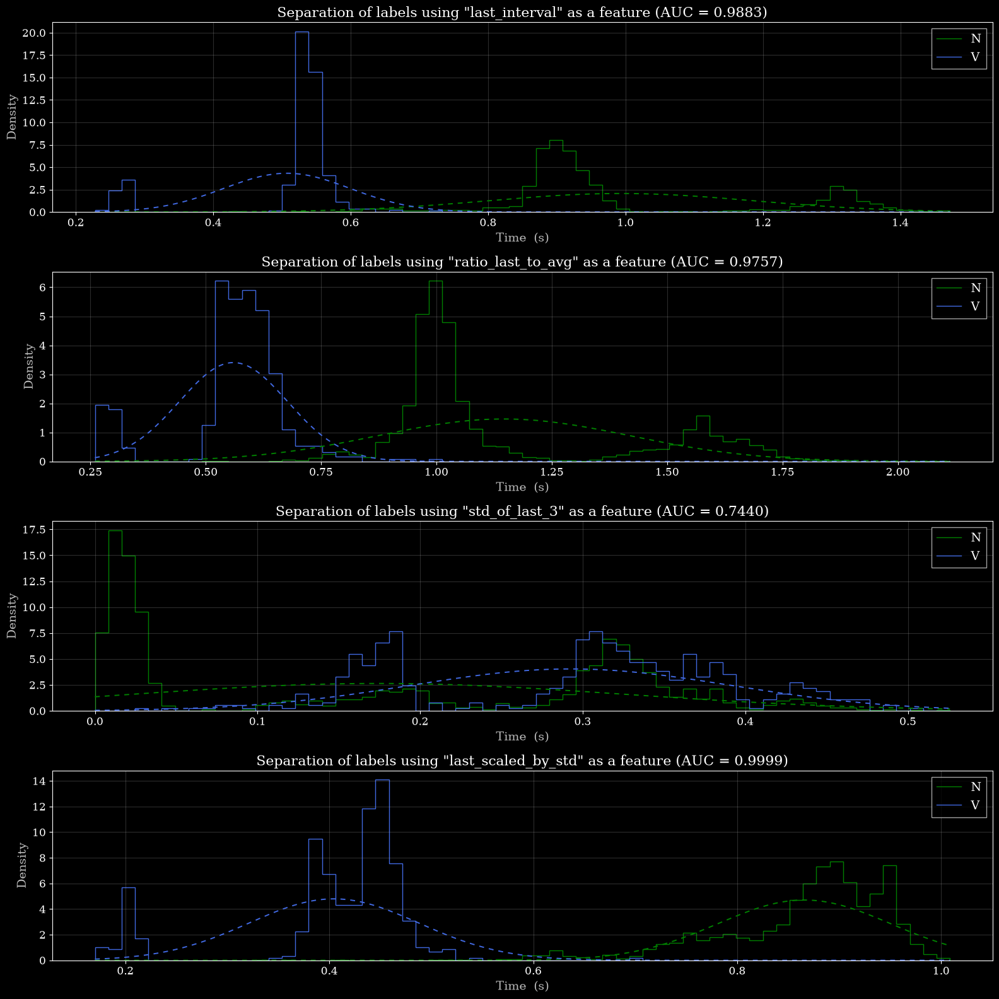

In [ ]:
# ── Task 3.1 (cont.): Visualize the candidate features ───────────────────────
# 📋 Side-by-side histograms + Gaussian fits for every candidate feature.
#    The feature with the cleanest visual separation should also have the
#    highest AUC. This is a sanity check on the table above.

# ── 🧠 Your solution — Task 3.1 (cont.) ─────────────────────────────────────────


# Imports
from typing import Dict

# Plot the subset of chosen features using the data on the summary dict
def plot_features(features_dict: Dict, selected_features: List[str], bins_num: int):
    num_feats = len(selected_features)
    fig, axes = plt.subplots(num_feats, 1, figsize=(16, 4*num_feats))

    # Filter dict to only get the features we are interested in
    filtered_feats_dict = {k: v for k, v in features_dict.items() if k in selected_features}
    for idx, (feat_name, feat_data) in enumerate(filtered_feats_dict.items()):
        # Get params from that feature
        x_plot = feat_data["x_plot"]
        mu_H0, sigma_H0 = feat_data["H0_params"]
        mu_H1, sigma_H1 = feat_data["H1_params"]

        # Get histogram bins for this feature
        tot_counts, bin_edges = np.histogram(x_plot, bins=bins_num)

        # Get H0 histogram and Gauss distribution
        axes[idx].stairs(*np.histogram(feat_data["feat_N"], bins=bin_edges, density=True),
                         color="green", linewidth=1.0, label="N")
        axes[idx].plot(x_plot, scipy.stats.norm.pdf(x_plot, loc=mu_H0, scale=sigma_H0),
                       color="green", linewidth=1.4, linestyle=(0, (4, 4)))

        # Get H1 histogram and Gauss distribution
        axes[idx].stairs(*np.histogram(feat_data["feat_V"], bins=bin_edges, density=True),
                         color="royalblue", linewidth=1.0, label="V")        
        axes[idx].plot(x_plot, scipy.stats.norm.pdf(x_plot, loc=mu_H1, scale=sigma_H1),
                       color="royalblue", linewidth=1.4, linestyle=(0, (4, 4)))

        # Visual details
        axes[idx].set_title(f"Separation of labels using \"{feat_name}\" as a feature (AUC = {feat_data['auc']:.4f})",
                            fontsize=16)
        axes[idx].set_ylabel("Density", fontsize=14)
        axes[idx].set_xlabel("Time  (s)", fontsize=14)
        axes[idx].grid(alpha=0.25)
        axes[idx].legend(loc="upper right", fontsize=14)

    plt.tight_layout()
    plt.show()


# Plot histograms and Gaussian distributions for each feature
plot_features(features_dict=feats_summary_dict, selected_features=chosen_features_list, bins_num=64)

##### 🧠 Your solution — Task 3.1

> Write your explanation here.


### 3.2 Neyman-Pearson Detector

The **Neyman-Pearson (NP) lemma** gives the most powerful test at false-alarm level $\alpha$. For Gaussian distributions the Log-Likelihood Ratio Test (Log-LRT) reduces to a threshold test. Assuming the feature is lower under $H_1$ (declare $H_1$ when $x < \gamma$):

$$P_{FA} = P(x < \gamma \mid H_0) = \Phi\!\left(\frac{\gamma - \mu_0}{\sigma_0}\right) = \alpha \quad\Longrightarrow\quad \boxed{\gamma_{\text{NP}} = \mu_0 + \sigma_0\,\Phi^{-1}(\alpha)}$$

#### 📋 Task 3.2

Evaluate the detector by building its **Receiver Operating Characteristic (ROC)** curve. Sweep a decision threshold across the full range of your selected feature and, at each threshold, measure two rates *empirically* from the class samples: the **false-alarm rate** $P_{FA}$ (fraction of Normal / $H_0$ beats wrongly flagged as PVC) and the **detection rate** $P_D$ (fraction of PVC / $H_1$ beats correctly flagged). Recall that $H_1$ is declared when the feature falls **below** the threshold. The provided code then computes the closed-form Neyman-Pearson threshold for the target $P_{FA} = 0.10$, marks that operating point on the ROC, and reports the empirical area under your ROC alongside the analytic Gaussian AUC. Confirm that the two AUC values agree.


Empirical AUC     : 0.9977
Analytic AUC      : 0.9999
NP threshold γ    : 0.757 s   (P_FA = 0.10, P_D = 1.000)


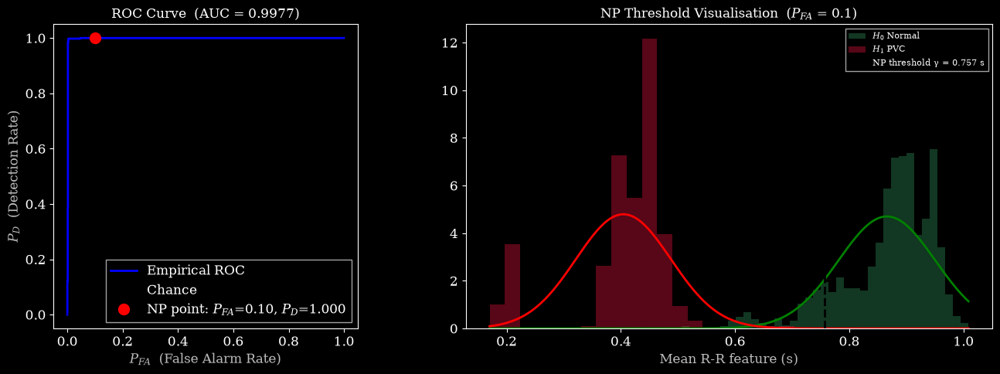

In [ ]:
# ── Task 3.2: ROC curve and NP threshold ──────────────────────────────────────
# 📋 Build the empirical ROC for the detector. Sweep a decision threshold γ
#    across the full range of the selected feature. Declare H1 (PVC) on the side
#    of γ where your feature places PVCs. Use feat < γ if PVCs take the LOWER
#    value, or feat > γ if they take the HIGHER value (check your 3.1 histograms).
#    At each γ, estimate two rates directly from the class samples and store:
#        thresholds  : the swept γ grid (cover the full feature range)
#        pfa_curve   : empirical false-alarm rate P_FA under H0 (from feat_N)
#        pd_curve    : empirical detection rate   P_D  under H1 (from feat_V)
#    The provided code below consumes these three arrays to locate the analytic
#    NP threshold at P_FA = 0.10, plot the ROC, and compare empirical vs
#    analytic AUC.

TARGET_PFA = 0.10

# ── 🧠 Your solution — Task 3.2 ────────────────────────────────────────────────
#    Required outputs (used by the provided ROC/AUC code and by Task 3.3):
#      thresholds – swept decision-threshold grid
#      pfa_curve  – empirical P_FA at each threshold
#      pd_curve   – empirical P_D  at each threshold
# 👇 your solution here — replace each TODO (or leave it if you don't know this task)

# For this feature, PVCs take LOWER values than Normal beats
thresholds = x_plot
pfa_curve = np.vectorize(lambda gamma: np.sum(feat_N < gamma) / len(feat_N))(thresholds)
pd_curve = np.vectorize(lambda gamma: np.sum(feat_V < gamma) / len(feat_V))(thresholds)


if answered(
    thresholds, pfa_curve, pd_curve, feat_N, feat_V, mu_H0, sigma_H0, mu_H1, sigma_H1, x_plot
):
    # Closed-form NP threshold and detection prob, works for either feature direction
    pvc_low = mu_H1 < mu_H0
    gamma_np = mu_H0 + sigma_H0 * scipy.stats.norm.ppf(TARGET_PFA if pvc_low else 1 - TARGET_PFA)
    pd_at_target = (
        scipy.stats.norm.cdf(gamma_np, mu_H1, sigma_H1)
        if pvc_low
        else scipy.stats.norm.sf(gamma_np, mu_H1, sigma_H1)
    )

    # AUC: empirical (trapezoidal rule) and analytic (Gaussian closed form)
    sort_idx = np.argsort(pfa_curve)
    auc_empirical = np.trapezoid(pd_curve[sort_idx], pfa_curve[sort_idx])
    auc_analytic = scipy.stats.norm.cdf(abs(mu_H0 - mu_H1) / np.sqrt(sigma_H0**2 + sigma_H1**2))

    print(f"Empirical AUC     : {auc_empirical:.4f}")
    print(f"Analytic AUC      : {auc_analytic:.4f}")
    print(
        f"NP threshold γ    : {gamma_np:.3f} s   (P_FA = {TARGET_PFA:.2f}, P_D = {pd_at_target:.3f})"
    )

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    # ROC curve
    axes[0].plot(pfa_curve[sort_idx], pd_curve[sort_idx], "b-", linewidth=2, label="Empirical ROC")
    axes[0].plot([0, 1], [0, 1], "k--", alpha=0.3, label="Chance")
    axes[0].plot(
        TARGET_PFA,
        pd_at_target,
        "ro",
        markersize=10,
        label=f"NP point: $P_{{FA}}$={TARGET_PFA:.2f}, $P_D$={pd_at_target:.3f}",
    )
    axes[0].set_xlabel("$P_{FA}$  (False Alarm Rate)")
    axes[0].set_ylabel("$P_D$  (Detection Rate)")
    axes[0].set_title(f"ROC Curve  (AUC = {auc_empirical:.4f})")
    axes[0].legend()
    axes[0].set_aspect("equal")

    # Feature distributions + NP threshold
    axes[1].hist(feat_N, bins=50, density=True, alpha=0.4, color="seagreen", label="$H_0$ Normal")
    axes[1].hist(feat_V, bins=20, density=True, alpha=0.4, color="crimson", label="$H_1$ PVC")
    axes[1].plot(x_plot, norm.pdf(x_plot, mu_H0, sigma_H0), "g-", linewidth=2)
    axes[1].plot(x_plot, norm.pdf(x_plot, mu_H1, sigma_H1), "r-", linewidth=2)
    axes[1].axvline(
        gamma_np,
        color="k",
        linestyle="--",
        linewidth=2,
        label=f"NP threshold γ = {gamma_np:.3f} s",
    )
    axes[1].set_xlabel("Mean R-R feature (s)")
    axes[1].set_title(f"NP Threshold Visualization  ($P_{{FA}}$ = {TARGET_PFA})")
    axes[1].legend(fontsize=8)

    plt.tight_layout()
    plt.show()
else:
    print("⚠️  Task 3.2 (or a prerequisite in Task 3.1) is unanswered, skipping the ROC/AUC figure.")

### 3.3 Operating Point Selection: Youden's J

The Neyman–Pearson point in Task 3.2 *fixes* the false-alarm rate at a chosen level. A different, equally common choice is the threshold that maximizes **Youden's J** statistic, $J = P_D - P_{FA}$, the vertical gap between the ROC curve and the chance diagonal. This is the operating point with the best *simultaneous* sensitivity and specificity, appropriate when a false alarm and a missed detection are treated as equally costly.

#### 📋 Task 3.3

Using the ROC sweep (`thresholds`, `pfa_curve`, `pd_curve`) from Task 3.2, find the threshold that maximizes Youden's J. Report the optimal threshold together with its $P_D$ and $P_{FA}$, and note from the output how this operating point compares with the NP point from Task 3.2. Does dropping the fixed-$P_{FA}$ constraint buy a higher detection rate?


In [ ]:
# ── Task 3.3: Optimal threshold via Youden's J statistic ─────────────────────
# 📋 Youden's J = P_D − P_FA is the vertical distance from the ROC curve to
#    the diagonal chance line. Maximizing J yields the threshold that gives
#    the best simultaneous sensitivity and specificity. It is the operating
#    point a clinician would choose if false alarms and missed detections are
#    equally costly.

# ── 🧠 Your solution — Task 3.3 ────────────────────────────────────────────────
#    Required outputs (used by the printout below):
#      J_statistic – Youden's J = P_D − P_FA at each threshold (array)
#      best_idx    – index of the maximum-J threshold
# 👇 your solution here — replace each TODO (or leave it if you don't know this task)
J_statistic = pd_curve - pfa_curve
best_idx = np.argmax(J_statistic)

if answered(J_statistic, best_idx, thresholds, pd_curve, pfa_curve):
    gamma_youden = thresholds[best_idx]
    pd_youden = pd_curve[best_idx]
    pfa_youden = pfa_curve[best_idx]

    print(f"Maximum Youden's J*  = {J_statistic[best_idx]:.3f}")
    print(f"Optimal threshold γ* = {gamma_youden:.3f} s")
    print(f"  P_D  (sensitivity) = {pd_youden:.3f}   ({pd_youden * 100:.1f}%)")
    print(f"  P_FA (1-specificity)= {pfa_youden:.3f}   ({pfa_youden * 100:.1f}%)")
    print(
        f"\n  Youden vs. NP:  J*(Youden) = {J_statistic[best_idx]:.3f}  "
        f"vs  J(NP) = {pd_at_target - TARGET_PFA:.3f}"
    )
else:
    print("⚠️  Task 3.3 (or a prerequisite) is unanswered, skipping the Youden-threshold report.")

Maximum Youden's J*  = 0.994
Optimal threshold γ* = 0.540 s
  P_D  (sensitivity) = 0.998   (99.8%)
  P_FA (1-specificity)= 0.004   (0.4%)

  Youden vs. NP:  J*(Youden) = 0.994  vs  J(NP) = 0.900


### 3.4 Bayesian Decision Rules (Ch 10)

Neyman-Pearson fixes a constraint on $P_{FA}$ and maximizes $P_D$ subject to it. The **Bayesian framework** takes a different starting point. It minimizes the weighted average of both error types, the **Bayes risk**:

$$R(\gamma) \;=\; P(H_0)\,C_{FP}\,P_{FA}(\gamma) \;+\; P(H_1)\,C_{FN}\,P_M(\gamma)$$

where $C_{FP}$ is the cost of a false alarm, $C_{FN}$ the cost of a missed PVC, $P_M(\gamma) = 1 - P_D(\gamma)$ the miss rate, and the priors $P(H_0), P(H_1)$ encode the class proportions you expect *a priori* (here, the empirical PVC burden of the recording). The optimal threshold

$$\gamma_{\text{Bayes}}^* \;=\; \arg\min_\gamma R(\gamma)$$

minimizes this risk. With equal costs $C_{FP} = C_{FN}$ this reduces to the **MAP detector**. With asymmetric costs (e.g. clinical screening, where missing a PVC is worse than a false alarm) the threshold shifts to favour sensitivity at the price of more false alarms.

#### 📋 Task 3.4

Using your canonical feature from Task 3.1, design the following three decision rules from the methods of Ch 10 and Ch 14:
1. **Neyman-Pearson** at $P_{FA} = 0.10$ (reuse $\gamma_{\text{NP}}$ from Task 3.2)
2. **MAP detector**, a Bayes-risk minimizer with equal costs $C_{FP} = C_{FN}$, priors $\hat P(H_0), \hat P(H_1)$ estimated empirically from the data
3. **Bayes-risk minimizer** with an *asymmetric* cost matrix you justify on clinical grounds (e.g. $C_{FN} = 5\,C_{FP}$ for a sensitivity-prioritising screening tool)

For each rule, compute $P_D$, $P_{FA}$, and a summary score you choose. Balanced accuracy $= \tfrac{1}{2}(P_D + 1 - P_{FA})$ is one option; for a screening tool, sensitivity (recall), specificity, Youden's J or the cost-weighted Bayes risk may make more sense. Choose one metric, justify it on clinical grounds, and implement the winning rule as `predict_pvc(feat)`.

Then comment on what you find, with emphasis on the clinical implications. Do the three rules give different operating points on this feature, and why or why not? Which rule would you use for VP-001, Neyman-Pearson's fixed false-alarm budget or a Bayesian weighted-risk rule, and what does that choice mean for the patient?


In [ ]:
# ── Task 3.4: Bayesian decision-rule design ──────────────────────────────────
# 📋 Using your canonical feature from Task 3.1, design ≥3 decision rules:
#       (1) Neyman-Pearson at TARGET_PFA          → reuse gamma_np from Task 3.2
#       (2) MAP detector                          → Bayes-risk minimizer, C_FN=C_FP=1
#       (3) Bayes-risk minimizer with an asymmetric cost matrix
#           (e.g. C_FN = 5·C_FP for a clinical screening tool)
#
#    For each rule report P_D, P_FA, and a summary score. Balanced accuracy
#    BalAcc = ½ (P_D + 1 − P_FA) is one option. A screening tool might instead
#    weight sensitivity or cost-weighted risk. Select a rule under the metric
#    you justify and promote it to predict_pvc(feat).

# ── 🧠 Your solution — Task 3.4 ────────────────────────────────────────────────

#  ─────────────────────────────  Helper functions ───────────────────────────────
def bayes_risk_func(
    feat_N: pd.Series, feat_V: pd.Series, prior_H0: float, prior_H1: float,
    cost_fp: float, cost_fn: float, gamma: float,
):
    prob_fa = np.sum(feat_N < gamma) / len(feat_N)
    prob_d = np.sum(feat_V < gamma) / len(feat_V)
    return (prior_H0 * cost_fp * prob_fa) + (prior_H1 * cost_fn * (1 - prob_d))


#  ─────────────────────────────  Main function ───────────────────────────────
def task_3_4(feat_N: pd.Series, feat_V: pd.Series, gamma_range: pd.Series, gamma_np: float):
    # Imports
    from functools import partial
    from sklearn.metrics import f1_score, fbeta_score

    # Calculate sample parameters for Bayes function
    prior_H0 = len(feat_N) / (len(feat_N) + len(feat_V))
    prior_H1 = len(feat_V) / (len(feat_N) + len(feat_V))
    # Update bayes risk function with constant params
    base_risk_func = partial(bayes_risk_func, feat_N, feat_V, prior_H0, prior_H1)

    # 2. MAP detector (Bayes risk minimizer with equal weights)
    cost_fp = cost_fn = 1
    risk_func_map = np.vectorize(partial(base_risk_func, cost_fp, cost_fn))
    risk_map = risk_func_map(gamma_range)
    gamma_map = gamma_range[np.argmin(risk_map)]

    # 3. Assymetric Bayes risk minizer
    cost_fp, cost_fn = 1, 5
    risk_func_assym = np.vectorize(partial(base_risk_func, cost_fp, cost_fn))
    risk_assym = risk_func_assym(gamma_range)
    gamma_assym = gamma_range[np.argmin(risk_assym)]

    # Create output summary
    summary_df = pd.DataFrame.from_dict({
        "method": ["NP", "MAP", "Assym"],
        "gamma": [gamma_np, gamma_map, gamma_assym]
    })

    # Get false alarm and detection metrics, based on gammas
    # Detection is equal to sensitivity, false alarm is equal to (1 - specificity)
    summary_df["false_alarm"] = summary_df["gamma"].apply(lambda gamma: np.sum(feat_N < gamma) / len(feat_N))
    summary_df["detection"] = summary_df["gamma"].apply(lambda gamma: np.sum(feat_V < gamma) / len(feat_V))

    # Get other summary scores
    y_true = np.array([False] * len(feat_N) + [True] * len(feat_V))
    summary_df["f1"] = summary_df["gamma"].apply(lambda gamma: f1_score(y_true, pd.concat([feat_N, feat_V]) < gamma))
    summary_df["f2"] = summary_df["gamma"].apply(lambda gamma: fbeta_score(y_true, pd.concat([feat_N, feat_V]) < gamma, beta=2))
    sensitivity_weight, false_alarm_weight = 5, 1
    summary_df["weighted_cost"] = sensitivity_weight*(1 - summary_df["detection"]) + false_alarm_weight*summary_df["false_alarm"]

    # Return final df
    return summary_df.set_index("method")

# Execute tasks
# Get outputs for this item
decisions_rules_df = task_3_4(feat_N=feat_N, feat_V=feat_V, gamma_range=thresholds, gamma_np=gamma_np)
# Promote chosen decision rule to a function
predict_pvc = lambda feat: bool(feat < decisions_rules_df.loc["Assym"]["gamma"])
# Have a look at the summary df
decisions_rules_df


,gamma,false_alarm,detection,f1,f2,weighted_cost
method,,,,,,
NP,0.757044,0.117111,1.000000,0.831461,0.925000,0.117111
MAP,0.523466,0.003253,0.995495,0.992144,0.994152,0.025776
Assym,0.540253,0.003904,0.997748,0.992161,0.995506,0.015165


##### 🧠 Your solution — Task 3.4

> Write your explanation here.


---
## Part 4 · Left Ventricular Ejection Fraction (30 pts)

### 4.1 Automatic LV Segmentation

We use the pre-trained **AugmentedCamusSeg** model, a deep neural network based on the U-Net architecture trained on the augmented CAMUS dataset, to automatically delineate the LV in each frame:

| Label | Region | Color |
|-------|--------|--------|
| 0 | Background | none |
| 1 | LV cavity | Red |
| 2 | Myocardium | Blue |

Once the LV mask is available for each frame, we identify **end-diastole (ED)** as the frame with the *largest* LV cavity area, and **end-systole (ES)** as the frame with the *smallest* LV cavity area.

#### 📋 Task 4.1

The provided cell below runs the segmentation model and stores the per-pixel class labels in `masks`, an array of shape $(N_{\text{frames}}, H, W)$. Your job is to turn those labels into clinical indices:

1. **Compute the LV cavity area per frame.** For each frame, count the pixels labeled as LV cavity (`label == 1`) and store the result in `lv_areas`, a length-$N_{\text{frames}}$ integer array, in px².
2. **Identify ED and ES.** `ed_idx` is the frame index with the *largest* `lv_areas`. `es_idx` is the frame index with the *smallest*.
3. **Report.** Print `ed_idx`, `es_idx`, and the full per-frame area table with the ED and ES rows flagged. The plotting code below the answer block will then overlay the segmentation on those two frames.

In [31]:
# ── Run LV segmentation model (provided) ─────────────────────────────────────
print("Loading AugmentedCamusSeg model...")
model_lv = AugmentedCamusSeg.from_preset("augmented_camus_seg")
print("Model loaded.")

# ONNX model expects NCHW format: (batch, channels, height, width)
echo_batch = echo_frames[..., None]  # (N, H, W, 1)
echo_batch = keras.ops.convert_to_tensor(echo_batch, dtype=np.float32)
# Model expects 256×256 input normalized to [-1, 1]
echo_batch = keras.ops.image.resize(echo_batch, (256, 256))
echo_batch = (echo_batch / 127.5) - 1.0
echo_nchw = keras.ops.transpose(echo_batch, (0, 3, 1, 2))  # (N, 1, 256, 256)
seg_output = model_lv.call(echo_nchw)  # (N, 3, 256, 256), 3-class logits

# Upsample the per-class output back to the original echo resolution so the
# segmentation overlay aligns with the ultrasound frame.
H, W = echo_frames.shape[1], echo_frames.shape[2]
seg_hwc = keras.ops.transpose(seg_output, (0, 2, 3, 1))  # (N, 256, 256, 3)
seg_full = keras.ops.image.resize(seg_hwc, (H, W), interpolation="bilinear")
masks = np.argmax(keras.ops.convert_to_numpy(seg_full), axis=-1)  # (N, H, W)

print(f"\nSegmentation masks shape : {masks.shape}")
print("Pixel labels             : 0 = background, 1 = LV cavity, 2 = myocardium")

Loading AugmentedCamusSeg model...


config.json:   0%|          | 0.00/428 [00:00<?, ?B/s]

2026-09-27 22:57:33.003911656 [W:onnxruntime:Default, device_discovery.cc:146 GetPciBusId] Skipping pci_bus_id for PCI path at "/sys/devices/LNXSYSTM:00/LNXSYBUS:00/PNP0A03:00/device:07/VMBUS:01/5620e0c7-8062-4dce-aeb7-520c7ef76171" because filename "5620e0c7-8062-4dce-aeb7-520c7ef76171" did not match expected pattern of [0-9a-f]+:[0-9a-f]+:[0-9a-f]+[.][0-9a-f]+


model.onnx: reconstructing file:   0%|          |  0.00B /  134MB            

model.onnx: downloading bytes:           |  0.00B            

Model loaded.

Segmentation masks shape : (17, 519, 630)
Pixel labels             : 0 = background, 1 = LV cavity, 2 = myocardium


Random frame drawn for illustration: 14


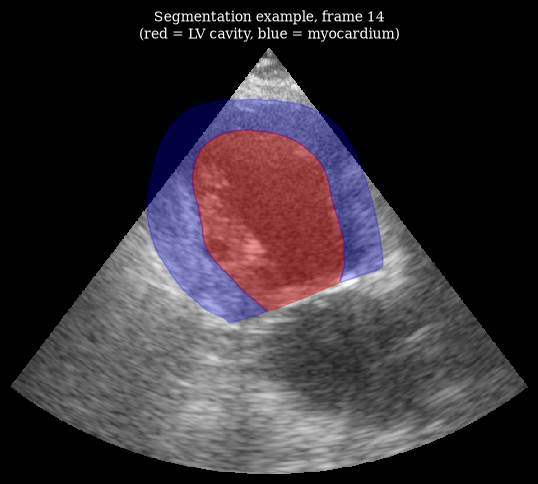

In [32]:
# ── Example: segmentation on one random frame (provided) ─────────────────────
# Pick an arbitrary frame to illustrate what the segmentation model produces.
# The draw is intentionally random. Identifying ED/ES is your job in Task 4.1.
example_idx = int(np.random.default_rng(0).integers(0, N_FRAMES))
print(f"Random frame drawn for illustration: {example_idx}")

fig, ax = plt.subplots(figsize=(6, 5))
ax.imshow(echo_frames[example_idx], cmap="gray", vmin=0, vmax=255)
plot_shape_from_mask(ax, masks[example_idx] == 1, color="red", alpha=0.35)
plot_shape_from_mask(ax, masks[example_idx] == 2, color="blue", alpha=0.25)
ax.set_title(
    f"Segmentation example, frame {example_idx}\n(red = LV cavity, blue = myocardium)", fontsize=10
)
ax.axis("off")
plt.tight_layout()
plt.show()

ED frame: 1  (A_ED = 38055 px²)
ES frame: 16  (A_ES = 29108 px²)

LV cavity area per frame:
  Frame  0:  37650 px
  Frame  1:  38055 px  ← ED (max)
  Frame  2:  37920 px
  Frame  3:  37266 px
  Frame  4:  36511 px
  Frame  5:  36245 px
  Frame  6:  35659 px
  Frame  7:  34052 px
  Frame  8:  33347 px
  Frame  9:  32577 px
  Frame 10:  32647 px
  Frame 11:  31787 px
  Frame 12:  30829 px
  Frame 13:  30509 px
  Frame 14:  30184 px
  Frame 15:  29452 px
  Frame 16:  29108 px  ← ES (min)


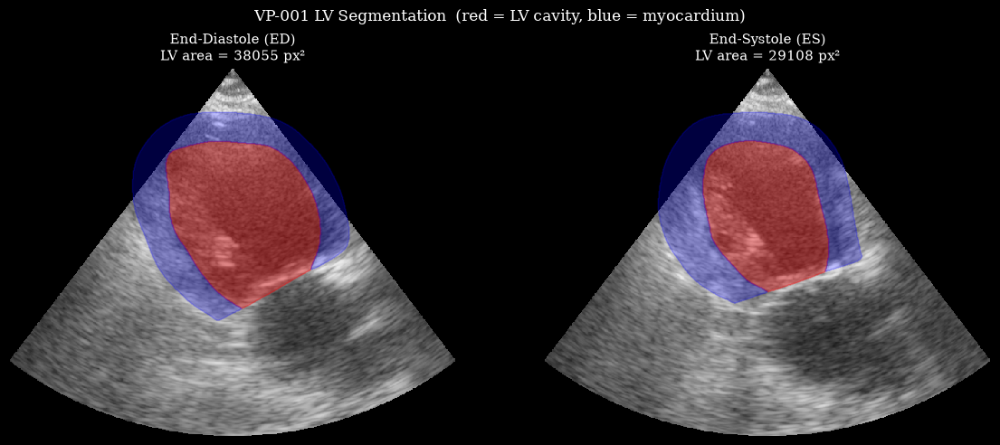

In [33]:
# ── Task 4.1: LV areas and ED/ES identification ──────────────────────────────
# Useful: np.sum() on a boolean mask, np.argmax(), np.argmin().

# ── 🧠 Your solution — Task 4.1 ────────────────────────────────────────────────
# 👇 your solution here — replace each TODO (or leave it if you don't know this task)
lv_areas = np.array([np.sum(frame == 1) for frame in masks])
ed_idx = np.argmax(lv_areas)
es_idx = np.argmin(lv_areas)

if answered(lv_areas, ed_idx, es_idx):
    print(f"ED frame: {ed_idx}  (A_ED = {lv_areas[ed_idx]} px²)")
    print(f"ES frame: {es_idx}  (A_ES = {lv_areas[es_idx]} px²)")

    print("\nLV cavity area per frame:")
    for i, a in enumerate(lv_areas):
        tag = ""
        if i == ed_idx:
            tag = "  ← ED (max)"
        if i == es_idx:
            tag = "  ← ES (min)"
        print(f"  Frame {i:2d}: {a:6d} px{tag}")

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    for ax, idx, label in zip(axes, [ed_idx, es_idx], ["End-Diastole (ED)", "End-Systole (ES)"]):
        ax.imshow(echo_frames[idx, :, :], cmap="gray", vmin=0, vmax=255)
        plot_shape_from_mask(ax, masks[idx] == 1, color="red", alpha=0.35)
        plot_shape_from_mask(ax, masks[idx] == 2, color="blue", alpha=0.25)
        ax.set_title(f"{label}\nLV area = {lv_areas[idx]} px²", fontsize=11)
        ax.axis("off")
    plt.suptitle("VP-001 LV Segmentation  (red = LV cavity, blue = myocardium)", fontsize=12)
    plt.tight_layout()
    plt.show()
else:
    print("⚠️  Task 4.1 is unanswered, skipping the ED/ES summary and figure.")

### 4.2 Calculating the Ejection Fraction

#### Method A: Fractional Area Change (FAC)

For a single apical view, EF can be approximated directly from pixel areas:

$$\text{FAC} = \frac{A_{\text{ED}} - A_{\text{ES}}}{A_{\text{ED}}} \times 100\%$$

This is dimensionless (pixel size cancels), so no calibration is required. Note that FAC is a **2D metric**: it captures how much the cross-sectional area decreases, but not how much the LV shortens along its long axis. The clinically defined EF is a 3D volume ratio. FAC approximates it, but the two are not equivalent.

#### Method B: Simpson's single-plane formula

The more clinically accepted approach approximates the LV as a prolate ellipsoid. For a single-plane view:

$$V = \frac{8\,A^2}{3\pi\,L}$$

where $A$ = LV cavity area (px²) and $L$ = LV long-axis length (px), measured from the apex to the mitral valve plane. Then:

$$\text{EF}_{\text{Simpson}} = \frac{V_{\text{ED}} - V_{\text{ES}}}{V_{\text{ED}}} \times 100\%$$

Because $V \propto A^2/L$, Simpson's method accounts for longitudinal shortening that FAC ignores.


#### 📋 Task 4.2a

Compute the area-method FAC (`EF_area`) directly from $A_{\text{ED}}$ and $A_{\text{ES}}$.


In [ ]:
A_ed = float(lv_areas[ed_idx])
A_es = float(lv_areas[es_idx])
print(f"A_ED = {A_ed:.0f} px²    A_ES = {A_es:.0f} px²")

# ── Task 4.2a: FAC ────────────────────────────────────────────────────────────
# ── 🧠 Your solution — Task 4.2a ───────────────────────────────────────────────
#    Required output (used by the printout below and Tasks 4.2c / 4.3):
#      EF_area – area-method (FAC) ejection fraction (%)
# 👇 your solution here — replace each TODO (or leave it if you don't know this task)
EF_area = (A_ed - A_es) / A_ed * 100

print(f"FAC (2D area method): {EF_area:.1f}%")

A_ED = 38055 px²    A_ES = 29108 px²
FAC (2D area method): 23.5%


#### 📋 Task 4.2b

**Implement** the `lv_long_axis_length()` helper in the cell below. Given a single binary LV-cavity mask `mask_lv` (one frame, shape `(H, W)`), extract the (row, col) image coordinates of every True pixel with `np.where`, then return the Euclidean distance between two centroids:

- **Apex**: the centroid (mean row, mean col) of the True pixels whose row index lies in the *bottom 10 % of the row range* (i.e. the *largest* row indices, the narrow tip of the cavity at the bottom of the image).
- **Base**: the centroid of the True pixels whose row index lies in the *top 10 % of the row range* (i.e. the *smallest* row indices, the mitral-valve plane at the top of the image).

Taking centroids over a 10 % vertical margin (rather than the single extreme row) keeps the estimate robust to one-pixel segmentation noise at either end.


In [ ]:
# ── Helper: estimate LV long-axis length from mask ────────────────────────────
def lv_long_axis_length(mask_lv: np.ndarray) -> float:
    """Estimate the LV long-axis length (in pixels) from a binary LV-cavity mask.

    Algorithm and rationale are described in the Task 4.2b prompt above.
    """
    # ── 🧠 Your solution — Task 4.2b ─────────────────────────────────────────
    # Get row and column indexes
    rows, cols = np.where(mask_lv)

    # TODO: not clear if they want bottom 10% of RANGE or of LENGTH
    cutoff=int((np.max(rows) - np.min(rows)) * 0.1)
    # cutoff = int(len(rows)*.1)

    # Calculate centroids
    apex = np.array([np.mean(rows[-cutoff:]), np.mean(cols[-cutoff:])])
    base = np.array([(np.mean(rows[:cutoff]), np.mean(cols[:cutoff]))])

    # Return distance
    return np.linalg.norm(apex - base)

#### 📋 Task 4.2c

Using your helper from 4.2b, compute the Simpson's-method EF (`EF_simpson`).

In [36]:
if answered(ed_idx, es_idx):
    L_ed = lv_long_axis_length(masks[ed_idx] == 1)
    L_es = lv_long_axis_length(masks[es_idx] == 1)
    print(f"L_ED = {L_ed:.1f} px    L_ES = {L_es:.1f} px")

    # ── Task 4.2c: Simpson's method EF ─────────────────────────────────────────────
    # ── 🧠 Your solution — Task 4.2c ───────────────────────────────────────────────
    #    Required outputs (used by the printout below):
    #      V_ed, V_es  – end-diastolic / end-systolic LV volumes (px³)
    #      EF_simpson  – Simpson single-plane ejection fraction (%)
    # 👇 your solution here — replace each TODO (or leave it if you don't know this task)
    V_ed = (8 / (3*np.pi)) * ((A_ed ** 2) / L_ed)
    V_es = (8 / (3*np.pi)) * ((A_es ** 2) / L_es)
    EF_simpson = (V_ed - V_es) / V_ed * 100

    print(f"\nV_ED = {V_ed:.0f} px³    V_ES = {V_es:.0f} px³")
    print(f"\nFAC (2D area method): {EF_area:.1f}%")
    print(f"EF (Simpson's rule) : {EF_simpson:.1f}%")
    print("\nClinical thresholds: ≥ 55% normal | 40–55% mildly reduced | < 40% reduced (HFrEF)")
    print(
        f"→ Classification   : {'NORMAL' if EF_area >= 55 else ('MILDLY REDUCED' if EF_area >= 40 else 'REDUCED (HFrEF)')}"
    )
else:
    print("⚠️  Task 4.2c needs Task 4.1 (ED/ES frames), skipping the Simpson's-rule EF report.")

L_ED = 235.6 px    L_ES = 212.4 px

V_ED = 5218280 px³    V_ES = 3385986 px³

FAC (2D area method): 23.5%
EF (Simpson's rule) : 35.1%

Clinical thresholds: ≥ 55% normal | 40–55% mildly reduced | < 40% reduced (HFrEF)
→ Classification   : REDUCED (HFrEF)


#### 📋 Task 4.2d

Compare the two methods quantitatively. Which gives a higher EF, and why?


##### 🧠 Your solution — Task 4.2d

> Write your explanation here.


### 🫀 Beating Heart Animation

The animation below cycles through all echo frames at physiological speed, overlaying the automatic LV segmentation. The three curves below it track key cardiac metrics across the cardiac cycle. They help you check visually that your ED and ES identifications are correct.

| Curve | What it shows |
|-------|--------------|
| **LV Cavity Area** | Should peak at ED (↑) and trough at ES (↓) |
| **LV Volume (Simpson's)** | Proportional to area²/length, same shape as area curve |
| **Myocardium Area** | Thickens during systole (wall thickening is a sign of healthy contractility) |

> Run the cell below. The animation plays in the notebook output. Dashed vertical lines mark your identified ED and ES frames. Check they align with the peaks and troughs of the curves.

In [37]:
if answered(ed_idx, es_idx, lv_areas) and answered(lv_long_axis_length(masks[ed_idx] == 1)):
    # ── Per-frame cardiac metrics ──────────────────────────────────────────────────
    myo_areas = np.array([np.sum(m == 2) for m in masks])  # myocardium wall area (px²)
    frame_idx = np.arange(N_FRAMES)

    L_all = np.array([lv_long_axis_length(masks[i] == 1) for i in range(N_FRAMES)])
    L_all = np.where(L_all < 1.0, 1.0, L_all)
    V_all = 8.0 * lv_areas**2 / (3.0 * np.pi * L_all)  # px³

    # Compute EF values locally (they may not be defined yet if cells run out of order)
    _A_ed = float(lv_areas[ed_idx])
    _A_es = float(lv_areas[es_idx])
    _L_ed = lv_long_axis_length(masks[ed_idx] == 1)
    _L_es = lv_long_axis_length(masks[es_idx] == 1)
    _EF_area = (_A_ed - _A_es) / _A_ed * 100
    _V_ed = 8 * _A_ed**2 / (3 * np.pi * _L_ed)
    _V_es = 8 * _A_es**2 / (3 * np.pi * _L_es)
    _EF_simpson = (_V_ed - _V_es) / _V_ed * 100

    # ── Figure layout ──────────────────────────────────────────────────────────────
    fig = plt.figure(figsize=(13, 8))
    gs = gridspec.GridSpec(2, 3, figure=fig, height_ratios=[1.5, 1.0], hspace=0.50, wspace=0.38)
    ax_echo = fig.add_subplot(gs[0, :])
    ax_area = fig.add_subplot(gs[1, 0])
    ax_vol = fig.add_subplot(gs[1, 1])
    ax_myo = fig.add_subplot(gs[1, 2])

    # ── Draw static background curves ─────────────────────────────────────────────
    curve_specs = [
        (ax_area, lv_areas, "LV area (px²)", "LV Cavity Area", "steelblue"),
        (ax_vol, V_all, "Volume (px³)", "LV Volume (Simpson's)", "darkorange"),
        (ax_myo, myo_areas, "Myocardium area (px²)", "Myocardium Wall Area", "crimson"),
    ]
    for ax, y, ylabel, title, color in curve_specs:
        ax.plot(frame_idx, y, "-o", color=color, markersize=4, linewidth=1.6)
        ax.axvline(
            ed_idx,
            color="seagreen",
            linestyle="--",
            linewidth=1.3,
            label=f"ED  (frame {ed_idx})",
        )
        ax.axvline(
            es_idx,
            color="firebrick",
            linestyle="--",
            linewidth=1.3,
            label=f"ES  (frame {es_idx})",
        )
        ax.set_xlabel("Frame index", fontsize=9)
        ax.set_ylabel(ylabel, fontsize=9)
        ax.set_title(title, fontsize=9, pad=4)
        ax.legend(fontsize=7, loc="upper right")
        ax.set_xlim(-0.5, N_FRAMES - 0.5)

    # ── Echo image artist ──────────────────────────────────────────────────────────
    def _make_rgba(mask_bool, rgb, alpha):
        rgba = np.zeros((mask_bool.shape[0], mask_bool.shape[1], 4), dtype=float)
        rgba[mask_bool, :3] = rgb
        rgba[mask_bool, 3] = alpha
        return rgba

    im = ax_echo.imshow(echo_frames[0], cmap="gray", vmin=0, vmax=255, animated=True)
    ov_lv = ax_echo.imshow(
        _make_rgba(masks[0] == 1, [1.0, 0.18, 0.18], 0.45),
        interpolation="nearest",
        animated=True,
    )
    ov_myo = ax_echo.imshow(
        _make_rgba(masks[0] == 2, [0.18, 0.42, 1.0], 0.32),
        interpolation="nearest",
        animated=True,
    )
    ax_echo.axis("off")

    title_txt = ax_echo.set_title("Frame 0", fontsize=11, pad=6)

    patches = [
        mpatches.Patch(color=(1.0, 0.18, 0.18, 0.6), label="LV cavity"),
        mpatches.Patch(color=(0.18, 0.42, 1.0, 0.5), label="Myocardium"),
    ]
    ax_echo.legend(
        handles=patches, loc="upper right", fontsize=9, framealpha=0.75, facecolor="white"
    )
    ax_echo.text(
        0.01,
        0.04,
        f"EF (area) = {_EF_area:.1f}%     EF (Simpson's) = {_EF_simpson:.1f}%",
        transform=ax_echo.transAxes,
        color="white",
        fontsize=10,
        bbox=dict(boxstyle="round,pad=0.35", facecolor="#0d3b6e", alpha=0.80),
    )

    vl_area = ax_area.axvline(0, color="black", linewidth=2.0, alpha=0.7, zorder=5)
    vl_vol = ax_vol.axvline(0, color="black", linewidth=2.0, alpha=0.7, zorder=5)
    vl_myo = ax_myo.axvline(0, color="black", linewidth=2.0, alpha=0.7, zorder=5)

    fig.suptitle(
        "VP-001: Beating Heart Animation with Automatic LV Segmentation",
        fontsize=12,
        y=1.005,
    )

    # ── Animation update function ──────────────────────────────────────────────────
    def _update(f):
        im.set_data(echo_frames[f])
        ov_lv.set_data(_make_rgba(masks[f] == 1, [1.0, 0.18, 0.18], 0.45))
        ov_myo.set_data(_make_rgba(masks[f] == 2, [0.18, 0.42, 1.0], 0.32))

        marker = "  ← ED" if f == ed_idx else ("  ← ES" if f == es_idx else "")
        title_txt.set_text(
            f"Frame {f:2d}{marker}    |    "
            f"LV area = {lv_areas[f]:4.0f} px²    |    "
            f"V = {V_all[f]:6.0f} px³    |    "
            f"Myo = {myo_areas[f]:4.0f} px²"
        )
        for vl in (vl_area, vl_vol, vl_myo):
            vl.set_xdata([f, f])
        return im, ov_lv, ov_myo, title_txt, vl_area, vl_vol, vl_myo

    anim = FuncAnimation(
        fig,
        _update,
        frames=N_FRAMES,
        interval=130,
        blit=True,
        repeat=True,
    )

    plt.close(fig)
    display(HTML(anim.to_jshtml()))
else:
    print("⚠️  Tasks 4.1/4.2b are unanswered, skipping the beating-heart animation.")

### 4.3 MLE and CRLB for the EF Estimate

The EF computed in Task 4.2 is based on a **single-frame** measurement, the argmax and argmin of the 17-frame sequence. This introduces two overlapping sources of uncertainty:

1. **Segmentation noise.** The neural-network mask has pixel-level errors on any given frame.
2. **Sampling uncertainty.** The true ED and ES instants fall *between* frames. The argmax frame is only the nearest sample to the true cardiac maximum. The measured area at that frame differs from the true peak area by however much the LV moved since the last frame.

Both sources cause the measured areas to deviate from the true peak values $\mu_{\text{ED}}$ and $\mu_{\text{ES}}$. We model the area of any near-ED frame $k$ and any near-ES frame $j$ as:

$$A^{(\text{ED})}_k = \mu_{\text{ED}} + \varepsilon_k, \qquad A^{(\text{ES})}_j = \mu_{\text{ES}} + \varepsilon_j, \qquad \varepsilon \sim \mathcal{N}(0,\,\sigma^2)$$

where $\mu_{\text{ED}},\,\mu_{\text{ES}}$ are the **true peak areas** at the exact cardiac extremes, and $\varepsilon$ lumps together segmentation noise and the displacement from the true extreme due to discrete sampling.

This CAMUS clip is a **half cardiac cycle**, ordered from end-diastole (frame 0, the largest cavity, i.e. the argmax) to end-systole (the final frame, the smallest, the argmin). So the **near-ED** window is the *first* few frames and the **near-ES** window is the *last* few frames. Together they span the plausible range of area values that could be measured for each cardiac phase under the given frame rate. Their standard deviation $\sigma$ is an empirical measure of the combined sampling-plus-segmentation uncertainty. It tells us how sensitive the EF estimate is to exactly which frame is declared the cardiac extreme.

> *Modeling note: $\varepsilon_k$ is not strictly i.i.d. The LV is still in motion between adjacent frames, so each near-ED frame samples a slightly different cardiac state (a systematic, not purely random, offset from $\mu_{\text{ED}}$). The Gaussian i.i.d. model is a working approximation. The resulting confidence interval (CI) is best read as a plausible range of EF values rather than a formal frequentist interval.*

#### 📋 Task 4.3a — Estimating $\sigma$

This clip runs from end-diastole (frame 0) to end-systole (the last frame), so the **near-ED** frames are the first three and the **near-ES** frames are the last three. Their standard deviation captures how much the measured area varies across frames that could reasonably be labeled as ED or ES given the sampling rate.

> Compute the standard deviation of LV areas over the near-ED frames (first 3) and the near-ES frames (last 3), and store them as `sigma_A_ed` and `sigma_A_es`. Then form the **pooled** estimate `sigma_A = (sigma_A_ed + sigma_A_es) / 2`, the single $\sigma$ used by the MLE and CRLB in Tasks 4.3b–d. Report all three.

In [38]:
# ── Task 4.3a: Estimate segmentation noise sigma_A ───────────────────────────
# 📋 CAMUS half-sequence runs ED → ES: ED is frame 0 (argmax), ES is the last
#    frame (argmin). So near-ED = the first 3 frames (0,1,2) and near-ES = the
#    last 3 frames (-3,-2,-1). Their std captures how much the measured area
#    varies across frames that could plausibly be called ED or ES. This is a mix
#    of segmentation noise and sampling uncertainty (cardiac motion between frames).
#    Compute std of lv_areas over each region (ddof=1), then pool: sigma_A =
#    (sigma_A_ed + sigma_A_es) / 2.

# ── 🧠 Your solution — Task 4.3a ───────────────────────────────────────────────
#    Required outputs (used by the printout below and Tasks 4.3b–d):
#      sigma_A_ed, sigma_A_es – std of near-ED / near-ES areas (px)
#      sigma_A                – pooled segmentation/sampling sigma (px)
# 👇 your solution here — replace each TODO (or leave it if you don't know this task)
sigma_A_ed = np.std(lv_areas[:3], ddof=1)
sigma_A_es = np.std(lv_areas[-3:], ddof=1)
sigma_A = (sigma_A_ed + sigma_A_es) / 2


print(
    f"sigma  near-ED  (frames 0-2)   : {sigma_A_ed:.1f} px  (sampling + segmentation uncertainty)"
)
print(
    f"sigma  near-ES  (frames -3:-1) : {sigma_A_es:.1f} px  (sampling + segmentation uncertainty)"
)
print(f"sigma  pooled                  : {sigma_A:.1f} px")

sigma  near-ED  (frames 0-2)   : 206.2 px  (sampling + segmentation uncertainty)
sigma  near-ES  (frames -3:-1) : 549.5 px  (sampling + segmentation uncertainty)
sigma  pooled                  : 377.9 px


#### 📋 Task 4.3b — Maximum Likelihood Estimation of $\mu_{\text{ED}}$ and $\mu_{\text{ES}}$

The near-ED areas are $N$ iid Gaussian observations $\{A_k\}_{k=1}^N$ with unknown mean $\mu$ and known variance $\sigma^2$ (the near-ES areas follow the same model). Starting from the model $A_k = \mu + \varepsilon_k$ above, derive the maximum-likelihood estimate of $\mu$.

> **First, derive it analytically** (write this in the solution box below). Write down the Gaussian log-likelihood $\ell(\mu)$, differentiate it with respect to $\mu$, set the derivative to zero, and show that $\hat{\mu}_{\text{MLE}} = \frac{1}{N}\sum_{k=1}^N A_k$.

> **Then, in code**, compute $\hat{\mu}_{\text{ED}}$ from the first $N_{\text{ED}} = 3$ frames and $\hat{\mu}_{\text{ES}}$ from the last $N_{\text{ES}} = 3$ frames, and report the resulting MLE for the FAC-based EF. Conceptually, what does averaging multiple near-ED frames give you compared to using the single argmax frame?

In [39]:
# ── Task 4.3b: MLE for mu_ED and mu_ES ───────────────────────────────────────
# 📋 Implement the MLE you derived above (the per-phase sample mean).
#    Use N_ED = 3 near-ED frames for mu_ED, N_ES = 3 near-ES frames for mu_ES.

# ── 🧠 Your solution — Task 4.3b ───────────────────────────────────────────────
#    Required outputs (used by the printout below and Tasks 4.3c–d):
#      N_ED, N_ES            – frames averaged per phase (= 3)
#      mu_ed_mle, mu_es_mle  – MLE mean ED / ES areas (px²)
#      EF_mle                – MLE-based ejection fraction (%)
# 👇 your solution here — replace each TODO (or leave it if you don't know this task)
N_ED = N_ES = 3
mu_ed_mle = np.mean(lv_areas[:3])
mu_es_mle = np.mean(lv_areas[-3:])
EF_mle = (mu_ed_mle - mu_es_mle) / mu_ed_mle * 100

# NOTE: wasnt the whole motivation finding more extreme values, instead of averages?
print(f"\nmu_ED  MLE (N={N_ED} frames): {mu_ed_mle:.1f} px^2   (single-frame: {A_ed:.1f} px^2)")
print(f"mu_ES  MLE (N={N_ES} frames): {mu_es_mle:.1f} px^2   (single-frame: {A_es:.1f} px^2)")
print(f"EF_MLE                     : {EF_mle:.1f}%")


mu_ED  MLE (N=3 frames): 37875.0 px^2   (single-frame: 38055.0 px^2)
mu_ES  MLE (N=3 frames): 29581.3 px^2   (single-frame: 29108.0 px^2)
EF_MLE                     : 21.9%


##### 🧠 Your solution — Task 4.3b

> Write your explanation here.


#### 📋 Task 4.3c — Fisher Information and CRLB

The log-likelihood $\ell(\mu)$ from Task 4.3b also sets a limit on how precise any unbiased estimator of $\mu$ can be.

> **First, derive it analytically** (write this in the solution box below). Starting from your $\ell(\mu)$, compute the Fisher information $\mathcal{I}(\mu) = -\mathbb{E}\!\left[\partial^2 \ell / \partial \mu^2\right]$ for a single observation, extend it to $N$ iid frames, and state the resulting Cramér-Rao lower bound on $\operatorname{Var}(\hat{\mu})$.

> **Then, in code**, evaluate the CRLB on $\hat{\mu}_{\text{ED}}$ for $N_{\text{ED}} = 1$ and $N_{\text{ED}} = 3$, verify that the MLE (sample mean) achieves the bound so it is an **efficient estimator**, and report by what factor averaging three near-ED frames reduces the standard deviation of the area estimate.

In [40]:
# ── Task 4.3c: Fisher information and CRLB for the area estimates ─────────────
# 📋 Evaluate the CRLB you derived above, Var(mu_hat) >= sigma_A^2 / N, for
#    N = 1 and N = N_ED, then check the sample-mean variance against it.

# ── 🧠 Your solution — Task 4.3c ───────────────────────────────────────────────
#    Required outputs (used by the printout below):
#      fisher_per_obs                 – Fisher information 1/σ² per frame
#      crlb_mu_1frame, crlb_mu_Nframe – CRLB on the area mean for N=1 / N=N_ED
# 👇 your solution here — replace each TODO (or leave it if you don't know this task)
fisher_per_obs = 1/(sigma_A**2)
crlb_mu_1frame = 1/fisher_per_obs
crlb_mu_Nframe = N_ED/fisher_per_obs


if answered(fisher_per_obs, crlb_mu_1frame, crlb_mu_Nframe):
    print(f"\nFisher info per obs  I(mu) = 1/sigma^2  : {fisher_per_obs:.6f}")
    print(
        f"CRLB  Var(mu_ED), N=1       : {crlb_mu_1frame:.1f} px^2  "
        f"(std = {np.sqrt(crlb_mu_1frame):.1f} px)"
    )
    print(
        f"CRLB  Var(mu_ED), N={N_ED}       : {crlb_mu_Nframe:.1f} px^2  "
        f"(std = {np.sqrt(crlb_mu_Nframe):.1f} px)  ({N_ED}x variance reduction)"
    )
else:
    print("⚠️  Task 4.3c is unanswered, skipping the Fisher-information / CRLB report.")


Fisher info per obs  I(mu) = 1/sigma^2  : 0.000007
CRLB  Var(mu_ED), N=1       : 142790.1 px^2  (std = 377.9 px)
CRLB  Var(mu_ED), N=3       : 428370.2 px^2  (std = 654.5 px)  (3x variance reduction)


##### 🧠 Your solution — Task 4.3c

> Write your explanation here.


#### 📋 Task 4.3d — CRLB for the EF: Parameter Transformation

The EF is a nonlinear function $g(\boldsymbol{\theta}) = (1 - \mu_{\text{ES}}/\mu_{\text{ED}}) \times 100$ of two independently estimated means $\boldsymbol{\theta} = (\mu_{\text{ED}},\,\mu_{\text{ES}})$. The joint Fisher information matrix is diagonal (independent estimation problems):

$$\mathbf{I}(\boldsymbol{\theta}) = \begin{pmatrix} N_{\text{ED}}/\sigma^2 & 0 \\ 0 & N_{\text{ES}}/\sigma^2 \end{pmatrix}$$

The CRLB for the transformed scalar parameter is:

$$\operatorname{Var}(\widehat{\text{EF}}) \geq \nabla g^\top \mathbf{I}^{-1} \nabla g = \left(\frac{\partial g}{\partial \mu_{\text{ED}}}\right)^2\!\frac{\sigma^2}{N_{\text{ED}}} + \left(\frac{\partial g}{\partial \mu_{\text{ES}}}\right)^2\!\frac{\sigma^2}{N_{\text{ES}}}$$

where $\partial g/\partial \mu_{\text{ED}} = (\mu_{\text{ES}}/\mu_{\text{ED}}^2)\times 100$ and $\partial g/\partial \mu_{\text{ES}} = (-1/\mu_{\text{ED}})\times 100$.

*Note: setting $N_{\text{ED}} = N_{\text{ES}} = 1$ recovers the classical delta method (single-frame).*

> Compute the CRLB-based 95 % CI on the FAC-based EF for $N_{\text{ED}} = N_{\text{ES}} = 3$. Compare the CI width to the single-frame ($N=1$) baseline. Then plot the 95 % CI full width as a function of $N$ (1 to 8 frames).

> **Then reflect** (in the solution box below). The plot makes the CI shrink as $N$ grows, which suggests that averaging ever more frames is always better. Is it? A tighter CI buys you precision at the cost of what? Think about what the extra frames actually contain as the window reaches further from the true ED and ES instants, and revisit the i.i.d. assumption in the modeling note above.

95% Confidence interval (N_ED = N_ES = 1) for EF:  [20.201, 25.174]%
95% Confidence interval (N_ED = N_ES = 3) for EF:  [20.465, 23.330]%


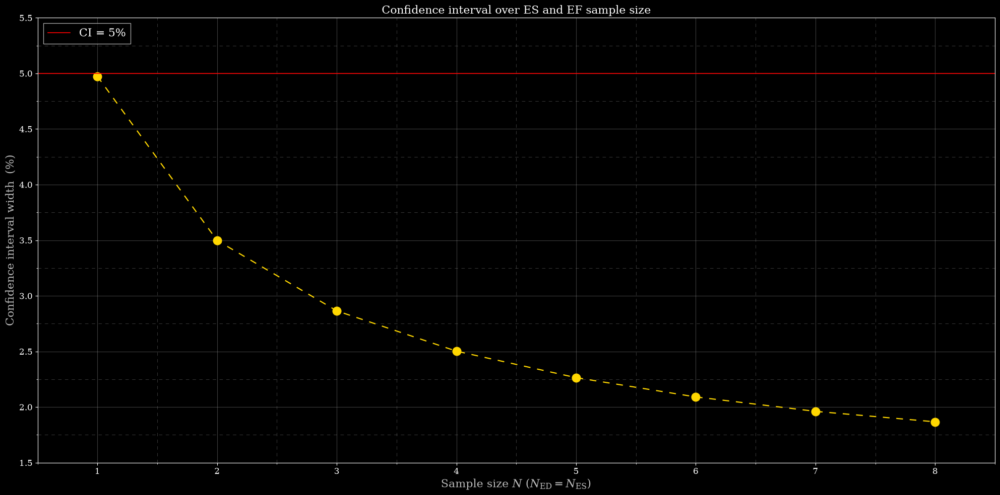

In [41]:
# ── Task 4.3d: CRLB for EF via parameter transformation ──────────────────────
# 📋 g(mu_ED, mu_ES) = (1 - mu_ES/mu_ED) * 100
#    Gradient:
#      dg/d_mu_ED = (mu_ES / mu_ED^2) * 100     [%/px^2]
#      dg/d_mu_ES = (-1   / mu_ED)    * 100     [%/px^2]
#    Joint Fisher info is diagonal (independent estimations):
#      I = diag(N_ED/sigma^2, N_ES/sigma^2)
#    CRLB for transformed parameter:
#      Var(EF_hat) >= (dg/d_mu_ED)^2 * sigma^2/N_ED + (dg/d_mu_ES)^2 * sigma^2/N_ES
#    Setting N_ED = N_ES = 1 recovers the classic single-frame delta method.
#
#    (1) Compute the CRLB-based 95% CI on the FAC-based EF for N_ED = N_ES = 3.
#        Also compute the N=1 (single-frame) baseline for comparison.
#    (2) Compute ci_widths: the 95% CI full width (2 * 1.96 * std_EF) for
#        N = 1 ... 8 frames per cardiac phase (N_ED = N_ES = N). Plot ci_widths
#        vs N. Mark where it first drops below 5 percentage points.

# ── 🧠 Your solution — Task 4.3d ───────────────────────────────────────────────

#  ─────────────────────────────  Helper functions ───────────────────────────────
# Calculate CRLB for the EF parameter, as a function of the sample sizes
def ef_crlb_per_sample_size(mu_ed: float, mu_es: float, sample_size_ed: float,
                            sample_size_es: float, lv_sigma: float):
    return (
        ((100 * lv_sigma) ** 2)
        * ((((mu_es / (mu_ed ** 2)) ** 2) / sample_size_ed)
          + (((-1 / mu_ed) ** 2) / sample_size_es))
    )

# Calculate confidence interval for the EF parameter, as a function of the sample sizes
def ef_ci_per_sample_size(lv_array: np.ndarray, sample_size_ed: float,
                          sample_size_es: float, lv_sigma: float, ci_level: float):
    # Get sample estimators
    mu_ed = np.mean(lv_array[:sample_size_ed])
    mu_es = np.mean(lv_array[-sample_size_es:])
    mu_ef = (mu_ed - mu_es) / mu_ed * 100

    # Calculate CRLB for a given sample size
    crlb = ef_crlb_per_sample_size(mu_ed=mu_ed, mu_es=mu_es, sample_size_ed=sample_size_ed,
                                   sample_size_es=sample_size_es, lv_sigma=lv_sigma)
    ef_std = np.sqrt(crlb)

    # Get precise z related to the confidence interval
    z = scipy.stats.norm.ppf((1 + ci_level) / 2, loc=0, scale=1)

    # Return lower and upper bounds
    return np.array([mu_ef - (z * ef_std), mu_ef + (z * ef_std)])

# Plot confidence interval widths as a function of the sample size
def plot_ci_widths(sampling_range: np.ndarray, ci_widths: np.ndarray):
    # Imports
    from matplotlib.ticker import MultipleLocator

    fig, axis = plt.subplots(1, 1, figsize=(20, 10))
    axis.plot(sampling_range, ci_widths, color="gold", marker="o", ms=12, linestyle=(0, (6, 6)), linewidth=1.6)
    axis.plot([0, 10], [5, 5], color="red", linewidth=1.2, label="CI = 5%")

    # Set text labels and axis ticks (purely aesthetic)
    axis.set_title("Confidence interval over ES and EF sample size", fontsize=16)
    axis.set_ylabel("Confidence interval width  (%)", fontsize=16)
    axis.set_xlabel(r"Sample size $N$ ($N_{\mathrm{ED}} = N_{\mathrm{ES}}$)", fontsize=16)
    axis.xaxis.set_major_locator(MultipleLocator(1))
    axis.xaxis.set_minor_locator(MultipleLocator(0.5))
    axis.yaxis.set_major_locator(MultipleLocator(0.5))
    axis.yaxis.set_minor_locator(MultipleLocator(0.25))
    axis.grid(which="major", axis="both", alpha=0.35)
    axis.grid(which="minor", axis="both", linestyle=(0, (6, 6)), alpha=0.3)
    axis.set_xlim(left=0.5, right=8.5)
    axis.set_ylim(bottom=1.5, top=5.5)
    axis.legend(fontsize=16, loc="upper left")

    plt.tight_layout()
    plt.show()


#  ─────────────────────────────  Main function ───────────────────────────────
# Calculate ci_widths for the EF parameter, as a function of the sample range required
def task_4_3d(lv_array: np.ndarray, lv_sigma: float, ci_level: float, sampling_range: np.ndarray):
    # Calculate confidence interval for N_ED = N_ES = 1
    ci_1_sample = ef_ci_per_sample_size(lv_array=lv_array, sample_size_ed=1, sample_size_es=1, lv_sigma=lv_sigma, ci_level=ci_level)
    print(f"95% Confidence interval (N_ED = N_ES = 1) for EF:  [{ci_1_sample[0]:.3f}, {ci_1_sample[1]:.3f}]%")
    # Calculate confidence interval for N_ED = N_ES = 3
    ci_3_samples = ef_ci_per_sample_size(lv_array=lv_array, sample_size_ed=3, sample_size_es=3, lv_sigma=lv_sigma, ci_level=ci_level)
    print(f"95% Confidence interval (N_ED = N_ES = 3) for EF:  [{ci_3_samples[0]:.3f}, {ci_3_samples[1]:.3f}]%")

    # Calculate confidence interval across whole sampling range
    ci_intervals = np.array(
        [ef_ci_per_sample_size(lv_array=lv_array, sample_size_ed=n,
                               sample_size_es=n, lv_sigma=lv_sigma, ci_level=ci_level)
        for n in sampling_range]
    )

    # Calculate total width across the range
    ci_widths = ci_intervals[:, 1] - ci_intervals[:, 0]

    # Show graph over sample range used
    plot_ci_widths(sampling_range=sampling_range, ci_widths=ci_widths)

    return ci_widths


# Perform task
sample_size_array = np.array(range(1, 9))
ci_widths = task_4_3d(lv_array=lv_areas, lv_sigma=sigma_A, ci_level=0.95, sampling_range=sample_size_array)

##### 🧠 Your solution — Task 4.3d

> Write your explanation here.


---
## Part 5 · Clinical Assessment (Bonus: +5 pts)

> **Bonus (+5 pts).** Write a short clinical report (≤ 400 words) in the markdown cell below addressing all four clinical questions from Dr. van den Berg's referral. Use your computed results, and explicitly link each conclusion to the statistical method that produced it.

##### 🧠 Your solution — Clinical Report

> Write your explanation here.


---
## Part 6 · Bonus Points Summary

Two optional bonuses can be added on top of your 100-point base grade:

| Bonus | Where | How it is earned | Max |
|-------|-------|------------------|-----|
| Clinical integration report | Part 5 | A correct, method-linked clinical report (≤ 400 words) | +5.0 |
| Extra detection features | Task 3.1 | +2.5 for each additional *distinct, well-analyzed* feature beyond the required three (≤ 2 extra) | +5.0 |

> The bonuses are optional extras on top of the four graded parts. There is **no scoreboard or ranking**; each group is graded on its own work.